# EDA — Detección de fraude eléctrico STEG (Fase 1)

El análisis exploratorio del proyecto se desarrolla íntegramente en este notebook, en el
orden que fija el protocolo de exploración: univariado, bivariado, multivariado, temporal
y relacional entre tablas, con las implicaciones para el modelado al cierre.

El cómputo genérico vive fuera. Cramér's V, Mann-Whitney con rank-biserial y su
bootstrap, los intervalos de Wilson, el KS de dos muestras, la información mutua contra
un nulo de permutación y la gramática visual están implementados como funciones puras y
sin opinión de negocio en `src/steg/eda/{univariate,bivariate,figures}.py`. Aquí se
decide qué mirar, se interpreta y se narra.

El perfilado de la Fase 0 (`src/steg/eda/profile.py`, `make audit`) se mantiene como
script porque es infraestructura repetible sin intervención humana. La exploración de la
Fase 1 la lee una persona y de ella salen decisiones, y por eso se documenta así.

## Regla de higiene, la que no se negocia

Todo análisis que mire `target` corre **exclusivamente** sobre
`client_train`/`invoice_train` o sobre agregados derivados de ellas. Las tablas de test
se cargan en la sección 4 con un único propósito, comparar distribuciones, que no
involucra la etiqueta porque en test no existe, y no vuelven a aparecer a partir de la
sección 5. Mirar variables explicativas de test contra la etiqueta de train sería fuga.

## Qué produce al ejecutarse

| Destino | Contenido |
|---|---|
| `reports/tables/*.csv` | toda cifra citada en los informes y en el manuscrito |
| `reports/figures/*.png` | figuras a 300 dpi con la gramática visual única del proyecto |
| `reports/EDA/01_univariate.md` | univariado, en texto plano |
| `reports/EDA/02_temporal_relational.md` | temporal y relacional |
| `reports/EDA/03_bivariate.md` | relación con la etiqueta |
| `reports/EDA/04_implicaciones.md` | las cuatro propuestas de decisión de la Fase 2 |
| `reports/DECISIONS.md` | las mismas cuatro, marcadas `PROPUESTA` |

Los `.md` recogen en texto plano la narrativa de estas celdas, de modo que las fases
posteriores puedan citarla sin abrir Jupyter.

**Cómo correrlo**: Kernel > Restart & Run All. Tarda del orden de diez minutos, casi
todo en el bootstrap de la sección 6 y en la información mutua de la sección 7. Parte
de `data/interim/*.parquet`, no de los CSV crudos: esas tablas ya traen las banderas de
anomalía de `src/steg/data/clean.py`.

In [1]:
%matplotlib inline

import sys
import warnings
from datetime import date

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# El paquete se instala con `pip install -e .`; el añadido a sys.path es una red de
# seguridad para que el notebook también corra en un entorno donde eso no se hizo.
sys.path.insert(0, str((__import__("pathlib").Path.cwd().parent / "src").resolve()))

from steg.config import (
    INTERIM_FILES,
    N_FOLDS,
    REPORTS_EDA_DIR,
    REPORTS_FIGURES_DIR,
    REPORTS_TABLES_DIR,
    SEED,
    DECISIONS_PATH,
)
from steg.data.split import assert_no_group_leakage, grouped_kfold_splits
from steg.eda import bivariate as biv
from steg.eda import figures as fg
from steg.eda import univariate as uni

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

fg.apply_style()
for d in (REPORTS_TABLES_DIR, REPORTS_FIGURES_DIR, REPORTS_EDA_DIR):
    d.mkdir(parents=True, exist_ok=True)

TODAY = date.today().isoformat()
RUN_STAMP = f"notebooks/01_eda.ipynb, ejecutado el {TODAY} con SEED={SEED}"
print(RUN_STAMP)

notebooks/01_eda.ipynb, ejecutado el 2026-09-18 con SEED=42


In [2]:
# Constantes del análisis. Viven aquí y no en config.py porque son decisiones de
# exploración de esta fase, no parámetros del pipeline de modelado.

VOLUME_BREAK_YEAR = 2005          # el volumen real de facturación arranca aquí (Fase 0)
TOP_K = uni.TOP_K_CATEGORIES      # categorías que se tabulan antes de agrupar en "otras"
N_BOOT = 400                      # remuestreos del bootstrap de rank-biserial
MI_SAMPLE = 40_000                # clientes para la información mutua
MI_PERMUTATIONS = 5               # barajados de target para el nulo de la MI

INVOICE_NUMERIC = [
    "consommation_level_1", "consommation_level_2", "consommation_level_3",
    "consommation_level_4", "old_index", "new_index", "months_number",
    "counter_coefficient",
]
INVOICE_CATEGORICAL = [
    "tarif_type", "counter_statue", "counter_code", "reading_remarque", "counter_type",
]
CLIENT_CATEGORICAL = ["disrict", "client_catg", "region"]
ANOMALY_FLAGS = [
    "logical_duplicate", "counter_statue_invalid", "reading_remarque_invalid",
    "months_number_invalid", "index_regression",
]
CONSUMPTION_LEVELS = [f"consommation_level_{i}" for i in (1, 2, 3, 4)]

def save_table(df, name):
    # Ningún número del manuscrito se escribe a mano: todo pasa por reports/tables/.
    path = REPORTS_TABLES_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"{path.name}: {len(df)} filas")
    return df

In [3]:
client_train = pd.read_parquet(INTERIM_FILES["client_train"])
invoice_train = pd.read_parquet(INTERIM_FILES["invoice_train"])
client_test = pd.read_parquet(INTERIM_FILES["client_test"])
invoice_test = pd.read_parquet(INTERIM_FILES["invoice_test"])

# Vista de client_train indexada por client_id. Es la que usa todo análisis que mira
# target: steg.eda.bivariate exige que la etiqueta y las explicativas lleven el mismo
# índice de client_id (train_*), no un RangeIndex. set_index no reordena filas, y se
# verifica: el orden posicional sigue siendo el de client_train, que es el que usan los
# splits de la sección 7.
client_train_idx = client_train.set_index("client_id", verify_integrity=True)
assert (client_train_idx.index.to_numpy() == client_train["client_id"].to_numpy()).all()

N_CLIENTS = len(client_train)
N_POS = int(client_train["target"].sum())
BASE_RATE = N_POS / N_CLIENTS

print(f"client_train  {client_train.shape}   invoice_train {invoice_train.shape}")
print(f"client_test   {client_test.shape}   invoice_test  {invoice_test.shape}")
print(f"positivos: {uni.mil(N_POS)} de {uni.mil(N_CLIENTS)} = {100 * BASE_RATE:.2f} %")

client_train  (135493, 6)   invoice_train (4476738, 21)
client_test   (58069, 5)   invoice_test  (1939722, 21)
positivos: 7.566 de 135.493 = 5.58 %


Las dimensiones reproducen las del perfilado de la Fase 0
(`reports/EDA/00_data_audit.md`) salvo por las filas exactamente duplicadas que elimina
`clean.py`: `invoice_train` baja de 4.476.749 a 4.476.738 filas, once menos, e
`invoice_test` de 1.939.730 a 1.939.722, ocho menos. Ninguna otra regla de limpieza borra
registros; las demás se limitan a marcar con una bandera booleana.

La tasa de positivos, 5,58 %, es la misma que reportó la Fase 0, y condiciona las cuatro
decisiones de la sección 9.

---
# 1. Univariado

Distribución de cada columna por sí sola; ninguna celda de esta sección mira `target`.

De las numéricas se reportan percentiles, sesgo, curtosis, masa exacta en cero y atípicos
por IQR robusto. La media y la desviación quedan relegadas porque en las columnas de
consumo la media está dominada por la cola y no describe a ningún cliente real.

In [4]:
numeric_profile = pd.concat(
    [
        uni.numeric_profile(invoice_train, INVOICE_NUMERIC, "invoice_train"),
        uni.numeric_profile(invoice_test, INVOICE_NUMERIC, "invoice_test"),
    ],
    ignore_index=True,
)

# El consumo total facturado es la magnitud que el contrato de datos dice que coincide
# con new_index - old_index en el 99,58 % de las filas. Se perfila aparte porque ninguno
# de los cuatro niveles por separado representa lo que consume el cliente.
for label, inv in (("invoice_train", invoice_train), ("invoice_test", invoice_test)):
    total = inv[CONSUMPTION_LEVELS].sum(axis=1)
    row = {"table": label, "column": "consommation_total (derivada)"}
    row.update(uni.describe_numeric(total))
    numeric_profile = pd.concat([numeric_profile, pd.DataFrame([row])], ignore_index=True)

save_table(numeric_profile, "univariate_numeric")
display(
    numeric_profile[numeric_profile["table"] == "invoice_train"][
        ["column", "pct_zero", "p25", "p50", "p75", "p99", "max", "mean", "std",
         "skew", "pct_outliers_high_iqr"]
    ].round(2)
)

univariate_numeric.csv: 18 filas


,column,pct_zero,p25,p50,p75,p99,max,mean,std,skew,pct_outliers_high_iqr
0,consommation_level_1,10.44,79.0,274.0,600.0,2192.00,999910.0,410.98,757.31,525.98,2.78
1,consommation_level_2,85.24,0.0,0.0,0.0,2069.00,999073.0,109.32,1220.12,338.89,14.76
2,consommation_level_3,95.90,0.0,0.0,0.0,800.00,64492.0,20.31,157.42,75.31,4.10
3,consommation_level_4,97.92,0.0,0.0,0.0,1222.00,547946.0,52.93,875.47,118.60,2.08
4,old_index,6.43,1791.0,7690.0,21660.0,150959.78,2800280.0,17767.01,40366.95,11.09,6.00
5,new_index,4.38,2056.0,8192.0,22343.0,155668.26,2870972.0,18349.72,40953.23,10.99,5.96
6,months_number,0.00,4.0,4.0,4.0,12.00,636624.0,44.83,3128.34,105.34,9.04
7,counter_coefficient,0.00,1.0,1.0,1.0,1.00,50.0,1.00,0.31,116.78,0.04
16,consommation_total (derivada),10.44,80.0,309.0,657.0,5046.00,999910.0,593.54,1775.23,166.45,7.38


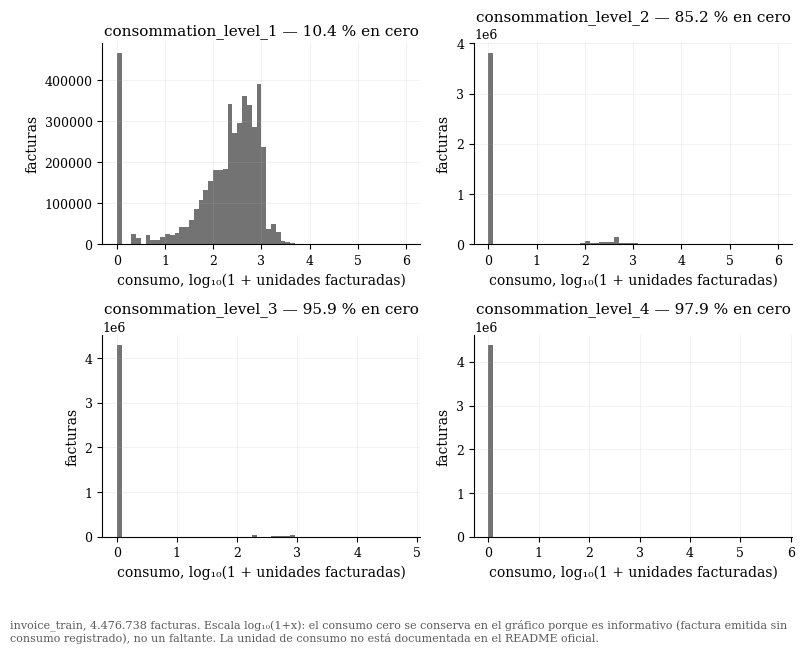

In [5]:
fig, axes = fg.plt.subplots(2, 2, figsize=fg.FIGSIZE_GRID)
for ax, col in zip(axes.ravel(), CONSUMPTION_LEVELS):
    fg.plot_log_histogram(ax, invoice_train[col].to_numpy(), color=fg.COLOR_NEUTRAL)
    ax.set_title(f"{col} — {100 * (invoice_train[col] == 0).mean():.1f} % en cero")
    ax.set_xlabel("consumo, log₁₀(1 + unidades facturadas)")
fig.tight_layout()
fg.add_caption(
    fig,
    f"invoice_train, {uni.mil(len(invoice_train))} facturas. Escala log₁₀(1+x): el "
    "consumo cero se conserva en el gráfico porque es informativo (factura emitida sin "
    "consumo registrado), no un faltante. La unidad de consumo no está documentada en "
    "el README oficial.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_univ_consumption_log_hist.png")

In [6]:
lv1 = numeric_profile.set_index(["table", "column"]).loc[("invoice_train", "consommation_level_1")]
print(f"consommation_level_1: mediana {lv1['p50']:.0f}, máximo {lv1['max']:.0f} "
      f"({lv1['max'] / lv1['p50']:.0f} veces la mediana)")
print(f"sesgo {lv1['skew']:.1f}, curtosis {lv1['kurtosis']:.0f}")
for c in CONSUMPTION_LEVELS[1:]:
    print(f"{c}: {numeric_profile.set_index(['table','column']).loc[('invoice_train', c), 'pct_zero']:.1f} % en cero")

consommation_level_1: mediana 274, máximo 999910 (3649 veces la mediana)
sesgo 526.0, curtosis 678682
consommation_level_2: 85.2 % en cero
consommation_level_3: 95.9 % en cero
consommation_level_4: 97.9 % en cero


`consommation_level_1` tiene mediana 274 y máximo 999.910, con sesgo del orden de 500.
Ninguna prueba que asuma normalidad tiene sentido sobre estas columnas, y de ahí que el
bivariado de la sección 6 recurra a Mann-Whitney en lugar de un t-test.

Los niveles 2, 3 y 4 están vacíos en el 85 %, 96 % y 98 % de las facturas. Tratarlos como
cuatro variables continuas comparables sería un error de lectura: en la práctica funcionan
como indicadores de que la factura superó un escalón tarifario. La Fase 3 tendría que
construirlos como "cuántas veces el cliente pasó del nivel 1", en vez de promediar una
columna que casi siempre vale cero.

El máximo de `months_number` es 636.624 en una columna que debería vivir en [1, 12]. Un
valor así desborda cualquier lectura como dato atípico y delata un campo corrupto, de modo
que la siguiente celda lo trata como lo que el protocolo indica para estos casos: un
faltante informativo.

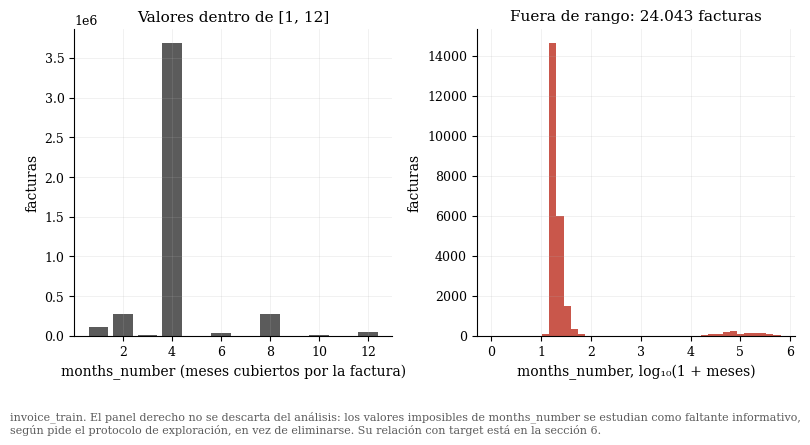

In [7]:
fig, axes = fg.plt.subplots(1, 2, figsize=fg.FIGSIZE_WIDE)

valid = invoice_train.loc[~invoice_train["months_number_invalid"], "months_number"]
vc = valid.value_counts().sort_index()
axes[0].bar(vc.index, vc.to_numpy(), color=fg.COLOR_NEUTRAL)
axes[0].set_xlabel("months_number (meses cubiertos por la factura)")
axes[0].set_ylabel("facturas")
axes[0].set_title("Valores dentro de [1, 12]")

invalid = invoice_train.loc[invoice_train["months_number_invalid"], "months_number"]
fg.plot_log_histogram(axes[1], invalid.to_numpy(), color=fg.COLOR_FRAUD, bins=40)
axes[1].set_xlabel("months_number, log₁₀(1 + meses)")
axes[1].set_title(f"Fuera de rango: {uni.mil(len(invalid))} facturas")

fig.tight_layout()
fg.add_caption(
    fig,
    "invoice_train. El panel derecho no se descarta del análisis: los valores imposibles "
    "de months_number se estudian como faltante informativo, según pide el protocolo de "
    "exploración, en vez de eliminarse. Su relación con target está en la sección 6.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_univ_months_number.png")

In [8]:
anomaly_rates = pd.concat(
    [
        uni.flag_rate_table(invoice_train, ANOMALY_FLAGS, "invoice_train"),
        uni.flag_rate_table(invoice_test, ANOMALY_FLAGS, "invoice_test"),
    ],
    ignore_index=True,
)
save_table(anomaly_rates, "univariate_anomaly_rates")
display(anomaly_rates)

univariate_anomaly_rates.csv: 10 filas


,table,flag,n_rows,n_flagged,pct_flagged,wilson_lo_pct,wilson_hi_pct,n_clients_affected
0,invoice_train,logical_duplicate,4476738,29278,0.6540,0.6466,0.6615,2191
1,invoice_train,counter_statue_invalid,4476738,47,0.0010,0.0008,0.0014,6
2,invoice_train,reading_remarque_invalid,4476738,34,0.0008,0.0005,0.0011,5
3,invoice_train,months_number_invalid,4476738,24043,0.5371,0.5303,0.5439,14944
4,invoice_train,index_regression,4476738,2264,0.0506,0.0485,0.0527,1816
5,invoice_test,logical_duplicate,1939722,14136,0.7288,0.7169,0.7408,964
6,invoice_test,counter_statue_invalid,1939722,0,0.0000,0.0000,0.0002,0
7,invoice_test,reading_remarque_invalid,1939722,0,0.0000,0.0000,0.0002,0
8,invoice_test,months_number_invalid,1939722,10401,0.5362,0.5260,0.5466,6296
9,invoice_test,index_regression,1939722,1054,0.0543,0.0512,0.0577,811


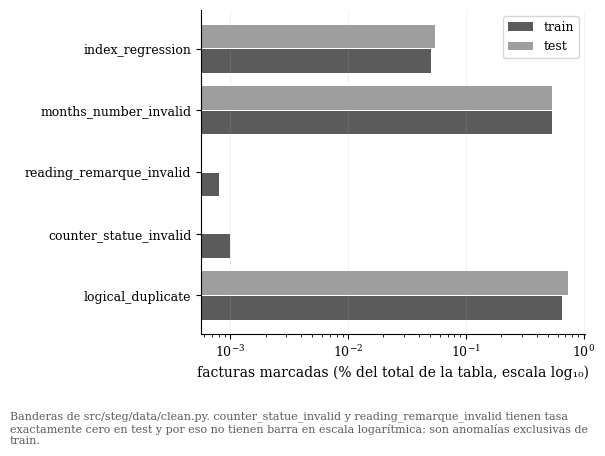

In [9]:
fig, ax = fg.plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
tr = anomaly_rates[anomaly_rates["table"] == "invoice_train"].set_index("flag")
te = anomaly_rates[anomaly_rates["table"] == "invoice_test"].set_index("flag")
flags = list(tr.index)
y = np.arange(len(flags))
ax.barh(y - 0.2, tr["pct_flagged"], height=0.38, color=fg.COLOR_TRAIN, label="train")
ax.barh(y + 0.2, te.reindex(flags)["pct_flagged"], height=0.38, color=fg.COLOR_TEST, label="test")
ax.set_yticks(y); ax.set_yticklabels(flags)
ax.set_xscale("log")
ax.set_xlabel("facturas marcadas (% del total de la tabla, escala log₁₀)")
ax.grid(axis="y", visible=False)
ax.legend()
fig.tight_layout()
fg.add_caption(
    fig,
    "Banderas de src/steg/data/clean.py. counter_statue_invalid y reading_remarque_invalid "
    "tienen tasa exactamente cero en test y por eso no tienen barra en escala logarítmica: "
    "son anomalías exclusivas de train.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_univ_anomaly_rates.png")

Este dataset no declara ni un solo nulo, pero sí tiene su equivalente: valores fuera de
rango que codifican "no se pudo leer" o "la captura se rompió". El protocolo pide
tratarlos como fenómeno en vez de imputarlos y seguir.

`months_number_invalid` afecta al 0,54 % de las facturas en train y al 0,54 % en test. Que
las dos tasas coincidan con tres decimales descarta un artefacto de la partición: el
defecto está en el sistema de facturación y atraviesa toda la base.

`counter_statue_invalid` (47 filas) y `reading_remarque_invalid` (34 filas) tienen tasa
**exactamente cero** en test. Bajo una partición aleatoria por cliente en proporción
70/30, 47 filas en train deberían venir acompañadas de unas 20 en test. Que no aparezca
ninguna apunta a un lote de registros de captura defectuosa que quedó entero de un lado.
El hallazgo tiene consecuencia directa: por mucho que la sección 6 les encuentre
asociación con `target`, una variable construida sobre esas banderas no sería reproducible
fuera de este train, y proponerla al modelo equivaldría a construir sobre un accidente de
la partición.

In [10]:
categorical_freq = pd.concat(
    [
        uni.categorical_profile(client_train, CLIENT_CATEGORICAL, "client_train", TOP_K),
        uni.categorical_profile(client_test, CLIENT_CATEGORICAL, "client_test", TOP_K),
        uni.categorical_profile(invoice_train, INVOICE_CATEGORICAL + ANOMALY_FLAGS, "invoice_train", TOP_K),
        uni.categorical_profile(invoice_test, INVOICE_CATEGORICAL + ANOMALY_FLAGS, "invoice_test", TOP_K),
    ],
    ignore_index=True,
)
save_table(categorical_freq, "univariate_categorical")

for table, col in (("client_train", "client_catg"), ("client_train", "disrict"),
                   ("client_train", "region"), ("invoice_train", "counter_type"),
                   ("invoice_train", "tarif_type")):
    sub = categorical_freq[(categorical_freq["table"] == table) & (categorical_freq["column"] == col)]
    top = sub.sort_values("n", ascending=False).iloc[0]
    print(f"{table}.{col}: {int(top['n_unique_original'])} valores, "
          f"el más frecuente `{top['value']}` con {top['pct']:.2f} %")

univariate_categorical.csv: 144 filas
client_train.client_catg: 3 valores, el más frecuente `11` con 97.05 %
client_train.disrict: 4 valores, el más frecuente `62` con 29.78 %
client_train.region: 25 valores, el más frecuente `101` con 24.92 %
invoice_train.counter_type: 2 valores, el más frecuente `ELEC` con 68.79 %
invoice_train.tarif_type: 17 valores, el más frecuente `11` con 59.86 %


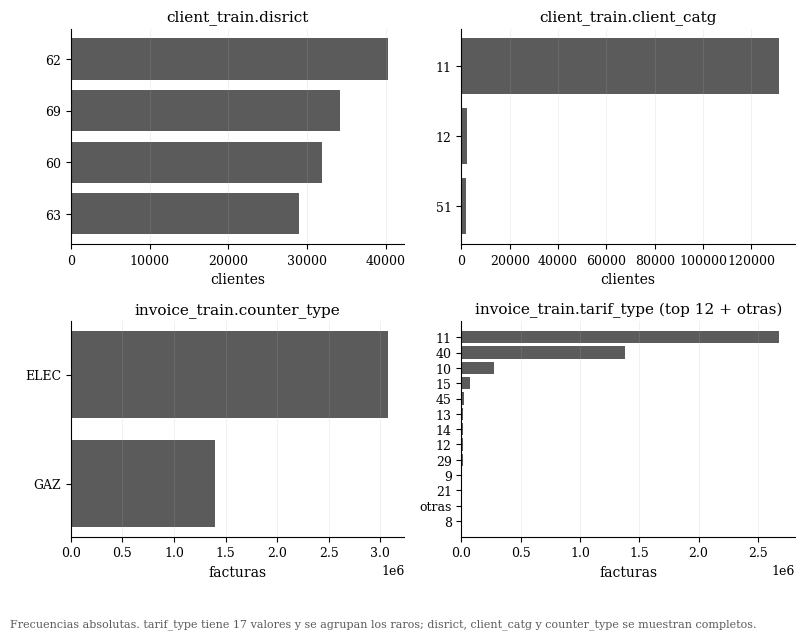

In [11]:
fig, axes = fg.plt.subplots(2, 2, figsize=fg.FIGSIZE_GRID)
spec = [
    (client_train, "disrict", "clientes", "client_train"),
    (client_train, "client_catg", "clientes", "client_train"),
    (invoice_train, "counter_type", "facturas", "invoice_train"),
    (invoice_train, "tarif_type", "facturas", "invoice_train"),
]
for ax, (df, col, unit, label) in zip(axes.ravel(), spec):
    values, grouped = uni.maybe_group(df[col], top_k=TOP_K)
    vc = values.value_counts()
    fg.plot_barh_frequency(ax, list(vc.index), list(vc.to_numpy()), xlabel=unit)
    ax.set_title(f"{label}.{col}" + (f" (top {TOP_K} + otras)" if grouped else ""))
fig.tight_layout()
fg.add_caption(
    fig,
    "Frecuencias absolutas. tarif_type tiene 17 valores y se agrupan los raros; disrict, "
    "client_catg y counter_type se muestran completos.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_univ_categorical_freq.png")

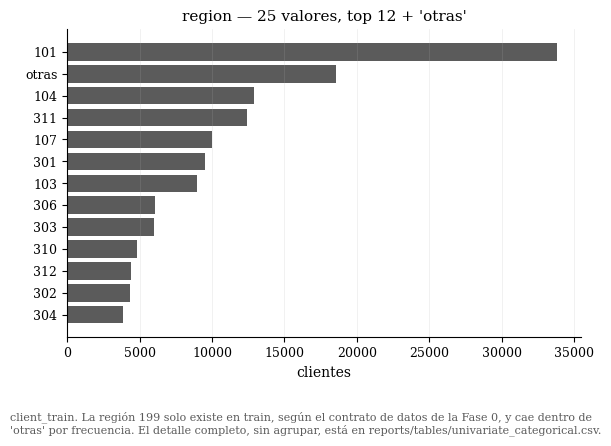

In [12]:
fig, ax = fg.plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
values, _ = uni.maybe_group(client_train["region"], top_k=TOP_K)
vc = values.value_counts()
fg.plot_barh_frequency(ax, list(vc.index), list(vc.to_numpy()), xlabel="clientes")
ax.set_title(f"region — {client_train['region'].nunique()} valores, top {TOP_K} + 'otras'")
fig.tight_layout()
fg.add_caption(
    fig,
    "client_train. La región 199 solo existe en train, según el contrato de datos de la "
    "Fase 0, y cae dentro de 'otras' por frecuencia. El detalle completo, sin agrupar, "
    "está en "
    "reports/tables/univariate_categorical.csv.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_univ_region_freq.png")

`client_catg` está tan concentrada que apenas funciona como variable: el valor 11 cubre el
97,05 % de los clientes y los otros dos se reparten 4.000 clientes entre ambos.
`counter_coefficient` repite el patrón en grado todavía más extremo, con el valor 1 en el
99,97 % de las filas.

`region` tiene 25 valores y las doce más frecuentes cubren el 86,3 % de los clientes. Esa
cola larga es justamente el caso que tendrá que resolver la decisión diferida sobre
codificación de categóricas de alta cardinalidad (Fase 3): una región con 300 clientes y
20 positivos no soporta un target encoding sin regularizar.

---
# 2. Temporal

El historial nominal cubre de 1977 a 2019, pero el volumen no está repartido. Cualquier
estadístico temporal tiene que declarar qué hace con el tramo residual, y por eso
cuantificarlo es el primer paso.

In [13]:
per_year = []
for label, inv in (("invoice_train", invoice_train), ("invoice_test", invoice_test)):
    s = inv["invoice_date"].dt.year.value_counts().sort_index()
    d = s.rename("n_invoices").rename_axis("year").reset_index()
    d["table"] = label
    d["pct"] = 100.0 * d["n_invoices"] / d["n_invoices"].sum()
    d["cum_pct"] = d["pct"].cumsum()
    per_year.append(d)
per_year = pd.concat(per_year, ignore_index=True)[["table", "year", "n_invoices", "pct", "cum_pct"]]
save_table(per_year, "temporal_invoices_per_year")

ty = per_year[per_year["table"] == "invoice_train"]
pre = ty[ty["year"] < VOLUME_BREAK_YEAR]
post = ty[ty["year"] >= VOLUME_BREAK_YEAR]
print(f"rango: {int(ty['year'].min())}–{int(ty['year'].max())}")
print(f"antes de {VOLUME_BREAK_YEAR}: {uni.mil(pre['n_invoices'].sum())} facturas "
      f"({pre['pct'].sum():.3f} %) repartidas en {len(pre)} años")
print(f"desde  {VOLUME_BREAK_YEAR}: {uni.mil(post['n_invoices'].sum())} facturas "
      f"({post['pct'].sum():.2f} %)")

temporal_invoices_per_year.csv: 86 filas
rango: 1977–2019
antes de 2005: 22.112 facturas (0.494 %) repartidas en 28 años
desde  2005: 4.454.626 facturas (99.51 %)


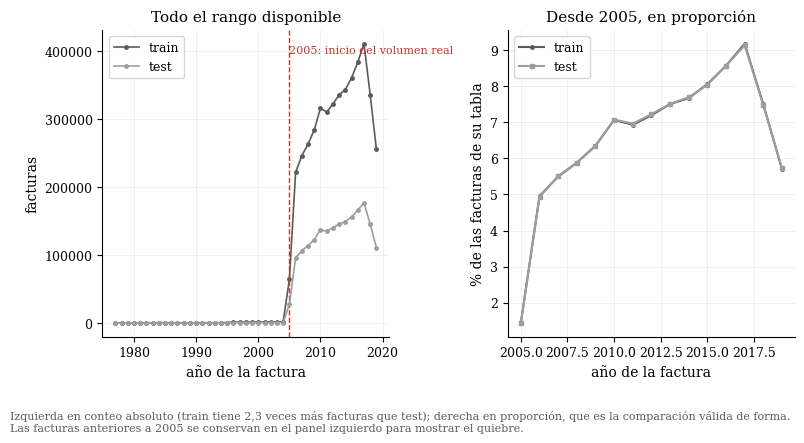

In [14]:
fig, axes = fg.plt.subplots(1, 2, figsize=fg.FIGSIZE_WIDE)
te_y = per_year[per_year["table"] == "invoice_test"]
fg.plot_year_series(axes[0], ty["year"], ty["n_invoices"], color=fg.COLOR_TRAIN, label="train")
fg.plot_year_series(axes[0], te_y["year"], te_y["n_invoices"], color=fg.COLOR_TEST,
                    label="test", mark_break=False)
axes[0].legend(); axes[0].set_title("Todo el rango disponible")

a = ty[ty["year"] >= VOLUME_BREAK_YEAR]
b = te_y[te_y["year"] >= VOLUME_BREAK_YEAR]
axes[1].plot(a["year"], a["pct"], color=fg.COLOR_TRAIN, marker="o", markersize=2.5, label="train")
axes[1].plot(b["year"], b["pct"], color=fg.COLOR_TEST, marker="s", markersize=2.5, label="test")
axes[1].set_xlabel("año de la factura")
axes[1].set_ylabel("% de las facturas de su tabla")
axes[1].set_title(f"Desde {VOLUME_BREAK_YEAR}, en proporción")
axes[1].legend()
fig.tight_layout()
fg.add_caption(
    fig,
    "Izquierda en conteo absoluto (train tiene 2,3 veces más facturas que test); derecha "
    "en proporción, que es la comparación válida de forma. Las facturas anteriores a 2005 "
    "se conservan en el panel izquierdo para mostrar el quiebre.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_temporal_invoices_per_year.png")

Los 28 años anteriores a 2005 suman 22.112 facturas, el 0,494 % del total: un residuo
compatible con lo que deja una migración de sistema, más que con un historial antiguo de
verdad. El corte de 2005 lo imponen los datos, no una elección analítica; es la fecha en
la que la tabla de facturación empieza a existir.

Eso reaparece en la sección 3. Para todos los clientes dados de alta antes de 2005 la
ventana de historial disponible está truncada por la izquierda por cómo se construyó la
base, y cualquier variable de "antigüedad del historial" mide en esos casos la fecha de la
migración.

Las curvas de train y test en proporción se superponen año a año con diferencias por
debajo de 0,05 puntos. La partición de Zindi no tiene corte temporal; la sección 4 lo
verifica formalmente.

In [15]:
per_month = []
for label, inv in (("invoice_train", invoice_train), ("invoice_test", invoice_test)):
    dates = inv.loc[inv["invoice_date"].dt.year >= VOLUME_BREAK_YEAR, "invoice_date"]
    s = dates.dt.month.value_counts().sort_index()
    d = s.rename("n_invoices").rename_axis("month").reset_index()
    d["table"] = label
    d["pct"] = 100.0 * d["n_invoices"] / d["n_invoices"].sum()
    per_month.append(d)
per_month = pd.concat(per_month, ignore_index=True)[["table", "month", "n_invoices", "pct"]]
save_table(per_month, "temporal_invoices_per_month")

fig, ax = fg.plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
for label, color, marker in (("invoice_train", fg.COLOR_TRAIN, "o"),
                             ("invoice_test", fg.COLOR_TEST, "s")):
    sub = per_month[per_month["table"] == label]
    ax.plot(sub["month"], sub["pct"], color=color, marker=marker, markersize=3, label=label)
ax.axhline(100 / 12, color=fg.COLOR_FRAUD, linestyle="--", linewidth=1.0)
ax.annotate("reparto uniforme (8,33 %)", xy=(1, 100 / 12), fontsize=8, color=fg.COLOR_FRAUD,
            va="bottom")
ax.set_xticks(range(1, 13))
ax.set_xlabel("mes del año de la factura")
ax.set_ylabel("% de las facturas de su tabla")
ax.legend()
fig.tight_layout()
fg.add_caption(
    fig,
    f"Solo facturas de {VOLUME_BREAK_YEAR} en adelante. Un perfil casi plano indica lectura "
    "repartida a lo largo del año, no ausencia de estacionalidad del consumo, que no es "
    "observable en esta tabla.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_temporal_invoices_per_month.png")

mtr = per_month[per_month["table"] == "invoice_train"].sort_values("pct")
print(f"mes con más facturas: {int(mtr.iloc[-1]['month'])} ({mtr.iloc[-1]['pct']:.2f} %)")
print(f"mes con menos:        {int(mtr.iloc[0]['month'])} ({mtr.iloc[0]['pct']:.2f} %)")
print(f"desviación máxima respecto del reparto uniforme: "
      f"{max(abs(mtr['pct'] - 100/12)):.2f} puntos porcentuales")

temporal_invoices_per_month.csv: 24 filas


mes con más facturas: 5 (9.35 %)
mes con menos:        12 (7.37 %)
desviación máxima respecto del reparto uniforme: 1.02 puntos porcentuales


La lectura de contadores se reparte a lo largo del año: la desviación máxima respecto del
8,33 % uniforme es de un punto porcentual. No hay campañas de lectura concentradas en un
trimestre, lo que descarta un sesgo que sí aparece en otras utilities, el de que el mes en
que a un cliente le toca lectura determine su perfil de consumo observado.

In [16]:
# Cobertura temporal por cliente. per_client_temporal calcula el hueco entre facturas de
# dos formas porque un cliente puede tener dos series en paralelo (ELEC y GAZ).
temporal_train = uni.per_client_temporal(invoice_train)
temporal_test = uni.per_client_temporal(invoice_test)

TEMPORAL_COLS = ["n_invoices", "span_years", "n_streams", "median_gap_days",
                 "max_gap_days", "median_gap_days_within_stream",
                 "max_gap_days_within_stream", "invoices_per_year"]
temporal_summary = pd.concat(
    [
        uni.summarize_columns(temporal_train, TEMPORAL_COLS, "invoice_train"),
        uni.summarize_columns(temporal_test, TEMPORAL_COLS, "invoice_test"),
    ],
    ignore_index=True,
)
save_table(temporal_summary, "temporal_client_summary")
display(temporal_summary[["table", "column", "n", "p01", "p25", "p50", "p75", "p99", "max"]].round(2))

temporal_client_summary.csv: 16 filas


,table,column,n,p01,p25,p50,p75,p99,max
0,invoice_train,n_invoices,135493,1.00,10.00,30.00,50.00,98.00,439.0
1,invoice_train,span_years,135493,0.00,3.33,9.31,13.32,14.45,14.9
2,invoice_train,n_streams,135493,1.00,1.00,1.00,2.00,2.00,2.0
3,invoice_train,median_gap_days,131281,0.00,4.00,106.00,122.00,366.00,3518.0
4,invoice_train,max_gap_days,131281,28.00,253.00,357.00,426.00,1446.40,3796.0
5,invoice_train,median_gap_days_within_stream,130422,0.00,119.00,121.00,125.00,397.00,3518.0
6,invoice_train,max_gap_days_within_stream,130422,62.00,256.00,364.00,450.00,1484.79,4208.0
7,invoice_train,invoices_per_year,130246,1.10,2.76,3.67,5.39,14.98,730.5
8,invoice_test,n_invoices,58069,1.00,11.00,30.00,50.00,103.00,412.0
9,invoice_test,span_years,58069,0.00,3.40,9.33,13.33,14.45,14.9


In [17]:
mix = (
    invoice_train.groupby("client_id", observed=True)["counter_type"]
    .agg(lambda s: "+".join(sorted(set(s))))
    .value_counts()
)
counter_mix = (
    mix.rename("n_clients").rename_axis("counter_type_mix").reset_index()
    .assign(pct=lambda d: (100.0 * d["n_clients"] / d["n_clients"].sum()).round(3))
)
save_table(counter_mix, "relational_counter_type_mix")
display(counter_mix)

ts = temporal_summary.set_index(["table", "column"])
print(f"hueco mediano sobre el flujo completo:      p25={ts.loc[('invoice_train','median_gap_days'),'p25']:.0f} d, "
      f"p50={ts.loc[('invoice_train','median_gap_days'),'p50']:.0f} d")
print(f"hueco mediano dentro de cada counter_type:  p25={ts.loc[('invoice_train','median_gap_days_within_stream'),'p25']:.0f} d, "
      f"p50={ts.loc[('invoice_train','median_gap_days_within_stream'),'p50']:.0f} d")

relational_counter_type_mix.csv: 3 filas


,counter_type_mix,n_clients,pct
0,ELEC,73439,54.201
1,ELEC+GAZ,61376,45.298
2,GAZ,678,0.5


hueco mediano sobre el flujo completo:      p25=4 d, p50=106 d
hueco mediano dentro de cada counter_type:  p25=119 d, p50=121 d


Conviene dejar por escrito una trampa de medición antes de que alguien construya una
variable encima. El 45,3 % de los clientes tiene contador eléctrico **y** de gas, y sus dos
series de facturas se intercalan en la tabla. Si el hueco entre facturas consecutivas se
mide sobre el flujo completo del cliente, la cadencia aparente se desploma: el percentil 25
del hueco mediano cae a 4 días, como si a una cuarta parte de los clientes se le leyera el
contador cada cuatro días.

Calculado dentro de cada `counter_type` por separado, el hueco mediano ronda los 120 días,
coherente con facturación cuatrimestral. Cualquier variable del tipo "meses sin lectura"
que la Fase 3 construya tiene que calcularse dentro del tipo de contador; sobre el flujo
mezclado mediría cuántos contadores tiene el cliente y no cuánto tiempo pasó sin que nadie
le leyera el medidor.

El percentil 99 del hueco máximo llega a 1.446 días: hay clientes con cuatro años seguidos
sin una sola factura dentro de su propio historial. Ese fenómeno sí merece modelarse, y es
de naturaleza distinta al ruido anterior.

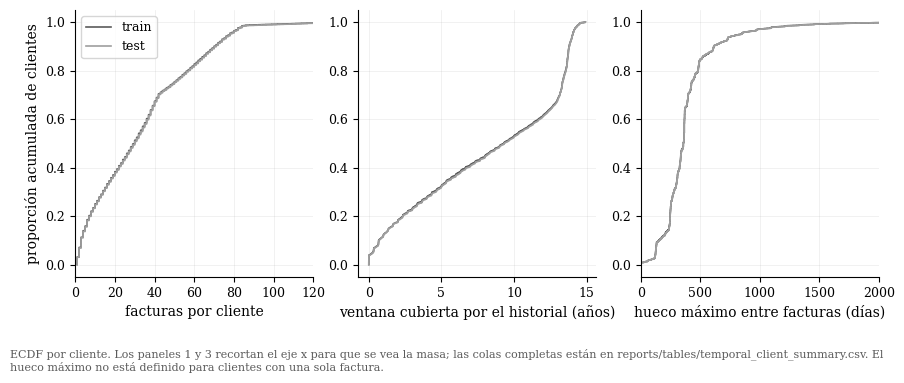

In [18]:
fig, axes = fg.plt.subplots(1, 3, figsize=(9.0, 3.4))
fg.plot_ecdf(axes[0], temporal_train["n_invoices"].to_numpy(), color=fg.COLOR_TRAIN, label="train")
fg.plot_ecdf(axes[0], temporal_test["n_invoices"].to_numpy(), color=fg.COLOR_TEST, label="test")
axes[0].set_xlabel("facturas por cliente"); axes[0].set_xlim(0, 120); axes[0].legend()

fg.plot_ecdf(axes[1], temporal_train["span_years"].to_numpy(), color=fg.COLOR_TRAIN)
fg.plot_ecdf(axes[1], temporal_test["span_years"].to_numpy(), color=fg.COLOR_TEST)
axes[1].set_xlabel("ventana cubierta por el historial (años)"); axes[1].set_ylabel("")

fg.plot_ecdf(axes[2], temporal_train["max_gap_days"].dropna().to_numpy(), color=fg.COLOR_TRAIN)
fg.plot_ecdf(axes[2], temporal_test["max_gap_days"].dropna().to_numpy(), color=fg.COLOR_TEST)
axes[2].set_xlabel("hueco máximo entre facturas (días)"); axes[2].set_ylabel("")
axes[2].set_xlim(0, 2000)

fig.tight_layout()
fg.add_caption(
    fig,
    "ECDF por cliente. Los paneles 1 y 3 recortan el eje x para que se vea la masa; las "
    "colas completas están en reports/tables/temporal_client_summary.csv. El hueco máximo "
    "no está definido para clientes con una sola factura.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_temporal_client_coverage.png")

La ventana del historial tiene mediana de 9,3 años y máximo de 14,9, casi exactamente la
distancia de 2005 a 2019. El techo lo impone la tabla, que no guarda nada anterior, y no la
antigüedad de los clientes. En el otro extremo, el percentil 1 vale 0,00: hay clientes con
todas sus facturas dentro del mismo día.

---
# 3. Relacional entre tablas (sin mirar la etiqueta)

Cómo se agregan las facturas por cliente, qué tan fiable es `counter_number` y si
`creation_date` dice lo que su nombre sugiere.

In [19]:
rows = []
for client_df, invoice_df, label in ((client_train, invoice_train, "client_train"),
                                     (client_test, invoice_test, "client_test")):
    counts = invoice_df.groupby("client_id", observed=True).size()
    counts = counts.reindex(client_df["client_id"], fill_value=0)
    row = {"table": label, "column": "n_invoices_per_client"}
    row.update(uni.describe_numeric(counts))
    for cut in (0, 1, 2, 3, 5, 10):
        row[f"n_clients_le_{cut}"] = int((counts <= cut).sum())
        row[f"pct_clients_le_{cut}"] = round(100.0 * float((counts <= cut).mean()), 4)
    rows.append(row)
invoices_per_client = pd.DataFrame(rows)
save_table(invoices_per_client, "relational_invoices_per_client")
display(invoices_per_client[["table", "n", "p01", "p50", "p99", "max",
                             "n_clients_le_0", "n_clients_le_1", "n_clients_le_3",
                             "n_clients_le_5", "n_clients_le_10"]])

relational_invoices_per_client.csv: 2 filas


,table,n,p01,p50,p99,max,n_clients_le_0,n_clients_le_1,n_clients_le_3,n_clients_le_5,n_clients_le_10
0,client_train,135493,1.0,30.0,98.0,439.0,0,4212,15269,21502,33931
1,client_test,58069,1.0,30.0,103.0,412.0,0,1760,6422,9034,14374


In [20]:
rows = []
for label, inv in (("invoice_train", invoice_train), ("invoice_test", invoice_test)):
    per_client = uni.counts_per_key(inv, "client_id", "counter_number")
    row = {"table": label, "column": "n_counter_number_per_client"}
    row.update(uni.describe_numeric(per_client))
    rows.append(row)

    # El valor 0 no es un contador: es el centinela de "sin número registrado". Meterlo
    # en el conteo de contadores compartidos inventa un contador con miles de clientes.
    nonzero = inv.loc[inv["counter_number"] != 0]
    per_counter = uni.counts_per_key(nonzero, "counter_number", "client_id")
    shared = per_counter.index[per_counter > 1]
    row = {"table": label, "column": "n_clients_per_counter_number (counter_number != 0)"}
    row.update(uni.describe_numeric(per_counter))
    row["n_counter_zero_rows"] = int((inv["counter_number"] == 0).sum())
    row["n_clients_with_counter_zero"] = int(inv.loc[inv["counter_number"] == 0, "client_id"].nunique())
    row["n_counters_shared_by_2plus_clients"] = int((per_counter > 1).sum())
    row["pct_counters_shared_by_2plus_clients"] = round(100.0 * float((per_counter > 1).mean()), 4)
    row["n_clients_touching_a_shared_counter"] = int(
        nonzero.loc[nonzero["counter_number"].isin(shared), "client_id"].nunique()
    )
    rows.append(row)
counters = pd.DataFrame(rows)
save_table(counters, "relational_counters")
display(counters[["table", "column", "n", "p50", "p75", "p99", "max",
                  "n_counter_zero_rows", "n_clients_with_counter_zero",
                  "n_counters_shared_by_2plus_clients",
                  "n_clients_touching_a_shared_counter"]])

relational_counters.csv: 4 filas


,table,column,n,p50,p75,p99,max,n_counter_zero_rows,n_clients_with_counter_zero,n_counters_shared_by_2plus_clients,n_clients_touching_a_shared_counter
0,invoice_train,n_counter_number_per_client,135493,2.0,2.0,4.0,8.0,NaN,NaN,NaN,NaN
1,invoice_train,n_clients_per_counter_number (counter_number !...,201892,1.0,1.0,3.0,23.0,43161.0,5149.0,20365.0,36602.0
2,invoice_test,n_counter_number_per_client,58069,2.0,2.0,4.0,8.0,NaN,NaN,NaN,NaN
3,invoice_test,n_clients_per_counter_number (counter_number !...,91965,1.0,1.0,2.0,11.0,18454.0,2196.0,4275.0,7802.0


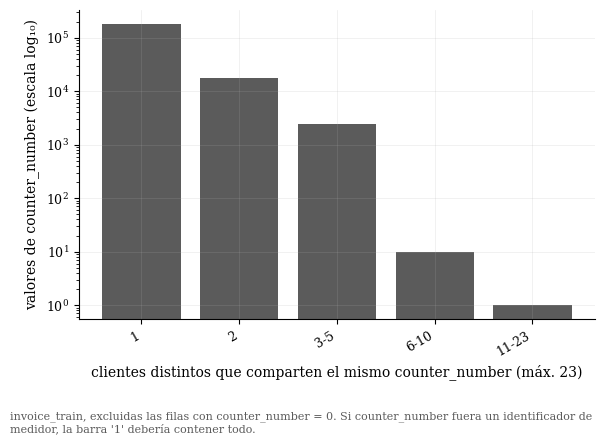

In [21]:
fig, ax = fg.plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
nonzero = invoice_train.loc[invoice_train["counter_number"] != 0]
per_counter = uni.counts_per_key(nonzero, "counter_number", "client_id")
top = int(per_counter.max())
edges = [e for e in (1, 2, 3, 6, 11, 51, 101) if e <= top] + [top + 1]
labels = [str(lo) if hi - lo == 1 else f"{lo}-{hi - 1}"
          for lo, hi in zip(edges[:-1], edges[1:])]
counts = pd.cut(per_counter, bins=edges, right=False, labels=labels).value_counts().reindex(labels)
ax.bar(range(len(labels)), counts.to_numpy(), color=fg.COLOR_NEUTRAL)
ax.set_yscale("log")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_xlabel(f"clientes distintos que comparten el mismo counter_number (máx. {top})")
ax.set_ylabel("valores de counter_number (escala log₁₀)")
fig.tight_layout()
fg.add_caption(
    fig,
    "invoice_train, excluidas las filas con counter_number = 0. Si counter_number fuera un "
    "identificador de medidor, la barra '1' debería contener todo.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_relational_counter_sharing.png")

### Corrección a una cifra de la Fase 0

El contrato de datos del proyecto afirmaba que 20.366 valores de `counter_number` están
compartidos por más de un cliente, uno de ellos por hasta 5.149. Ese cálculo incluía el
valor `0`, que funciona como centinela de "sin número registrado" y no como contador: los
5.149 son los clientes que tienen al menos una factura con `counter_number = 0`, y no
clientes que compartan un medidor físico.

Excluido el centinela quedan **20.365 valores compartidos** sobre 201.892 distintos
(10,09 %), y el máximo real de clientes por contador baja a **23**. El fenómeno se
sostiene con otra magnitud: una décima parte de los números de contador sigue apareciendo
en más de un cliente, y 36.602 clientes tocan al menos uno. El contrato de datos se
corrigió con estas cifras en el mismo cambio que este notebook.

La consecuencia práctica se mantiene: `counter_number` no identifica lo que su nombre
sugiere, y la Fase 3 tiene que usarlo como conteo (cuántos contadores distintos aparecen
en el historial del cliente), nunca como identidad ni como categórica.

In [22]:
rows = []
for client_df, temporal_df, label in ((client_train, temporal_train, "client_train"),
                                      (client_test, temporal_test, "client_test")):
    merged = client_df[["client_id", "creation_date"]].merge(
        temporal_df[["client_id", "first_invoice", "last_invoice"]], on="client_id", how="left"
    )
    delta = (merged["first_invoice"] - merged["creation_date"]).dt.days
    n = int(delta.notna().sum())
    n_before = int((delta < 0).sum())
    lo, hi = uni.wilson_interval(n_before, n)
    row = {
        "table": label,
        "column": "days_creation_to_first_invoice",
        "n_clients_with_invoices": n,
        "n_first_invoice_before_creation": n_before,
        "pct_first_invoice_before_creation": round(100.0 * n_before / n, 4),
        "wilson_lo_pct": round(100.0 * lo, 4),
        "wilson_hi_pct": round(100.0 * hi, 4),
        "median_days_before_when_negative": float(delta[delta < 0].median()),
    }
    row.update(uni.describe_numeric(delta))
    rows.append(row)
creation_vs_first = pd.DataFrame(rows)
save_table(creation_vs_first, "relational_creation_vs_first_invoice")
display(creation_vs_first[["table", "n_first_invoice_before_creation",
                           "pct_first_invoice_before_creation", "wilson_lo_pct",
                           "wilson_hi_pct", "median_days_before_when_negative",
                           "min", "p25", "p50", "p75", "max"]])

relational_creation_vs_first_invoice.csv: 2 filas


,table,n_first_invoice_before_creation,pct_first_invoice_before_creation,wilson_lo_pct,wilson_hi_pct,median_days_before_when_negative,min,p25,p50,p75,max
0,client_train,8748,6.4564,6.3268,6.5885,-75.0,-322.0,86.0,350.0,3890.0,13314.0
1,client_test,3677,6.3321,6.1369,6.5331,-77.0,-323.0,86.0,374.0,3941.0,13043.0


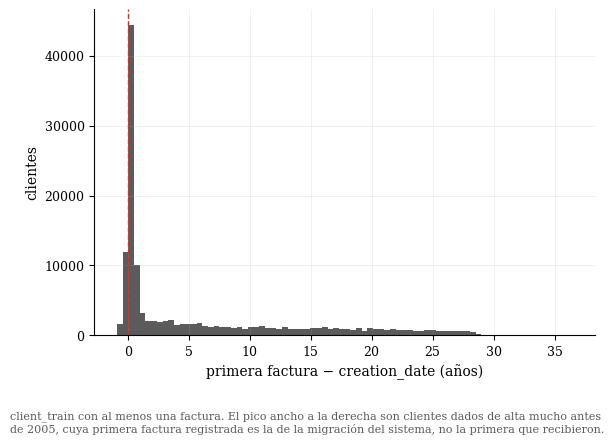

In [23]:
fig, ax = fg.plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
merged = client_train[["client_id", "creation_date"]].merge(
    temporal_train[["client_id", "first_invoice"]], on="client_id", how="inner"
)
delta_years = (merged["first_invoice"] - merged["creation_date"]).dt.days / 365.25
ax.hist(delta_years, bins=80, color=fg.COLOR_NEUTRAL)
ax.axvline(0.0, color=fg.COLOR_FRAUD, linestyle="--", linewidth=1.0)
n_before = int((delta_years < 0).sum())
ax.annotate(f"{uni.mil(n_before)} clientes con facturas\nanteriores a su alta",
            xy=(-24, ax.get_ylim()[1] * 0.55), fontsize=8, color=fg.COLOR_FRAUD)
ax.set_xlabel("primera factura − creation_date (años)")
ax.set_ylabel("clientes")
fig.tight_layout()
fg.add_caption(
    fig,
    "client_train con al menos una factura. El pico ancho a la derecha son clientes dados "
    "de alta mucho antes de 2005, cuya primera factura registrada es la de la migración "
    "del sistema, no la primera que recibieron.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_relational_creation_vs_first_invoice.png")

8.748 clientes de train (6,46 %, IC Wilson 95 % [6,33 %, 6,59 %]) tienen su primera
factura antes de la fecha de alta registrada. La Fase 0 ya los había contado; lo que añade
este análisis es la **magnitud** del desfase: mediana de 75 días en esos casos y máximo de
322, sin un solo cliente que se adelante más de un año.

Eso cambia la lectura. Un desfase de tres meses entre el inicio del suministro y el
registro administrativo del contrato es lo esperable en una utility con facturación
cuatrimestral, y se explica mejor por el retardo del trámite que por una inconsistencia
estructural entre las dos tablas.

El problema real está en el otro extremo de la distribución. El percentil 75 de
`primera factura − creation_date` es de 3.890 días, casi once años, y el máximo llega a
13.314 (36 años). Ningún cliente esperó once años a recibir su primera factura: son altas
de los años ochenta cuya facturación solo existe en la tabla desde 2005. La variable mide
truncamiento de la base, no antigüedad del cliente.

Consecuencia para la Fase 3: una antigüedad calculada como `hoy − creation_date` es
interpretable; una calculada como `primera factura − creation_date` mide la migración
del sistema; y una calculada como `última factura − primera factura` está acotada
artificialmente a 15 años para todo el mundo. Las tres son construibles, las tres
significan cosas distintas, y hay que elegir a sabiendas.

---
# 4. Train contra test

Última sección en la que aparecen las tablas de test. La comparación de distribuciones no
involucra `target`, que en test no existe, y por eso está permitida: sirve para saber si la
partición de Zindi deforma alguna variable antes de construir nada encima.

Con 135.493 y 58.069 clientes, y millones de facturas, el p-valor de cualquiera de estas
pruebas rechaza por diferencias irrelevantes. Lo que se lee es el tamaño del efecto contra
su referencia: el D crítico al 5 % para el KS, y la diferencia máxima de cuota en puntos
porcentuales para Cramér's V.

In [24]:
drift_rows = []

for col in CLIENT_CATEGORICAL:
    drift_rows.append(uni.compare_categorical(client_train[col], client_test[col], col, "cliente"))
drift_rows.append(uni.compare_numeric(
    client_train["creation_date"].dt.year, client_test["creation_date"].dt.year,
    "creation_date (año)", "cliente", "año"))

for col in INVOICE_NUMERIC:
    drift_rows.append(uni.compare_numeric(invoice_train[col], invoice_test[col], col,
                                          "factura", "unidades de consumo / meses"))
drift_rows.append(uni.compare_numeric(
    invoice_train["invoice_date"].dt.year, invoice_test["invoice_date"].dt.year,
    "invoice_date (año)", "factura", "año"))
for col in INVOICE_CATEGORICAL + ANOMALY_FLAGS:
    drift_rows.append(uni.compare_categorical(invoice_train[col], invoice_test[col], col, "factura"))

# La comparación que de verdad importa: la unidad de modelado es el cliente, no la factura.
for col, unit in (("n_invoices", "facturas"), ("span_years", "años"),
                  ("median_gap_days_within_stream", "días"), ("max_gap_days", "días"),
                  ("invoices_per_year", "facturas/año")):
    drift_rows.append(uni.compare_numeric(temporal_train[col], temporal_test[col], col,
                                          "cliente (agregado)", unit))

drift = pd.DataFrame(drift_rows).sort_values("effect_size", ascending=False).reset_index(drop=True)
save_table(drift, "train_test_drift")
display(drift[["level", "column", "effect_size_name", "effect_size", "reference_name",
               "reference", "max_abs_share_diff_pp", "p_value", "n_train", "n_test"]])

train_test_drift.csv: 28 filas


,level,column,effect_size_name,effect_size,reference_name,reference,max_abs_share_diff_pp,p_value,n_train,n_test
0,factura,counter_code,Cramér's V (corregida),0.056073,mínima celda esperada,1784.500000,0.3075,0.000000e+00,4476738,1939722
1,factura,new_index,D,0.009095,D crítico 5 %,0.004301,NaN,1.298367e-07,4476738,1939722
2,factura,old_index,D,0.008985,D crítico 5 %,0.004301,NaN,1.932769e-07,4476738,1939722
3,factura,tarif_type,Cramér's V (corregida),0.008659,mínima celda esperada,22.070000,0.1230,6.615414e-98,4476738,1939722
4,cliente (agregado),span_years,D,0.006545,D crítico 5 %,0.006746,NaN,6.117923e-02,135493,58069
5,cliente (agregado),n_invoices,D,0.005314,D crítico 5 %,0.006746,NaN,2.004213e-01,135493,58069
6,cliente (agregado),median_gap_days_within_stream,D,0.004824,D crítico 5 %,0.006872,NaN,3.208492e-01,130422,55967
7,cliente,creation_date (año),D,0.004232,D crítico 5 %,0.006746,NaN,4.592620e-01,135493,58069
8,factura,logical_duplicate,Cramér's V (corregida),0.004170,mínima celda esperada,13124.230000,0.0748,2.697845e-26,4476738,1939722
9,cliente (agregado),invoices_per_year,D,0.004028,D crítico 5 %,0.006877,NaN,5.482055e-01,130246,55895


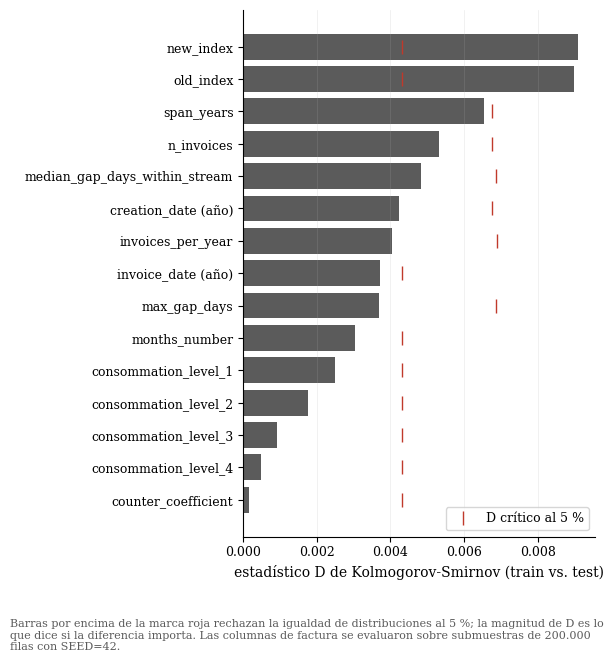

In [25]:
fig, ax = fg.plt.subplots(figsize=fg.FIGSIZE_TALL)
sub = drift[drift["test"] == "KS dos muestras"].sort_values("effect_size")
y = np.arange(len(sub))
ax.barh(y, sub["effect_size"], color=fg.COLOR_NEUTRAL)
ax.plot(sub["reference"], y, color=fg.COLOR_FRAUD, linestyle="none", marker="|",
        markersize=10, label="D crítico al 5 %")
ax.set_yticks(y); ax.set_yticklabels(sub["column"])
ax.set_xlabel("estadístico D de Kolmogorov-Smirnov (train vs. test)")
ax.grid(axis="y", visible=False)
ax.legend()
fig.tight_layout()
fg.add_caption(
    fig,
    "Barras por encima de la marca roja rechazan la igualdad de distribuciones al 5 %; la "
    "magnitud de D es lo que dice si la diferencia importa. Las columnas de factura se "
    f"evaluaron sobre submuestras de {uni.mil(uni.SAMPLE_SIZE)} filas con SEED={SEED}.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_traintest_ks.png")

In [26]:
ks = drift[drift["test"] == "KS dos muestras"]
cat = drift[drift["test"] != "KS dos muestras"]
print(f"{int((ks['effect_size'] > ks['reference']).sum())} de {len(ks)} numéricas superan su D crítico")
print(f"mayor D:  {ks.iloc[0]['column']} = {ks.iloc[0]['effect_size']:.4f} "
      f"(crítico {ks.iloc[0]['reference']:.4f})")
top_cat = cat.iloc[0]
print(f"mayor V:  {top_cat['column']} = {top_cat['effect_size']:.4f}, "
      f"diferencia máxima de cuota {top_cat['max_abs_share_diff_pp']:.2f} puntos porcentuales")

2 de 15 numéricas superan su D crítico
mayor D:  new_index = 0.0091 (crítico 0.0043)
mayor V:  counter_code = 0.0561, diferencia máxima de cuota 0.31 puntos porcentuales


El mayor desajuste numérico corresponde a `new_index`, con D = 0,0091 frente a un crítico
de 0,0043: significativo y sin ninguna importancia práctica. En categóricas el máximo es
`counter_code`, con V corregida de 0,056, que traducida a lo que se puede ver en una tabla
equivale a 0,23 puntos porcentuales de diferencia en la cuota de la categoría más
desplazada.

La partición de Zindi se comporta, por tanto, como un muestreo aleatorio por cliente. Su
única excepción estructural escapa a estas pruebas y la detectó la sección 1:
`counter_statue_invalid` y `reading_remarque_invalid` tienen tasa cero en test.

A partir de aquí no se vuelve a tocar `client_test` ni `invoice_test`.

In [27]:
# Cierre explícito de la regla de higiene: las tablas de test se liberan de memoria antes
# de que empiece cualquier análisis que mire la etiqueta.
del client_test, invoice_test, temporal_test
print("client_test / invoice_test liberadas. El resto del notebook solo ve la partición de entrenamiento.")

client_test / invoice_test liberadas. El resto del notebook solo ve la partición de entrenamiento.


---
# 5. Agregado exploratorio a nivel cliente

Relacionar el historial de facturación con la etiqueta exige una tabla con una fila por
cliente. La que se construye aquí es **exploratoria y no es el conjunto de variables de
modelado**, por motivos que conviene dejar escritos para que nadie la importe por error en
la Fase 4.

Se calcula **una vez sobre todo `invoice_train`**, fuera de cualquier fold, mientras que
el conjunto oficial se construye dentro de un `Pipeline` por fold (sección 2 de
`contextPrompt.md`) porque cualquier estadístico ajustado sobre el total contamina la
validación. Usa además el historial completo del cliente sin decidir ventana temporal, una
decisión que está diferida a la Fase 3. Y de propósito incluye variables que la sección 6
va a descartar, como las tasas de `counter_statue_invalid`, para poder mostrar por qué se
descartan.

El prefijo `exp_` marca esa condición en cada columna. Las variables definitivas llevarán
`inv_`, `cli_` o `rel_` y se construyen en la Fase 3.

In [28]:
inv = invoice_train
flags = pd.DataFrame({
    "client_id": inv["client_id"],
    "cons_total": inv[CONSUMPTION_LEVELS].sum(axis=1),
    "index_delta": inv["new_index"] - inv["old_index"],
    "is_gaz": inv["counter_type"].eq("GAZ"),
    "statue_nonzero": inv["counter_statue"].ne("0"),
    "months_number": inv["months_number"].where(~inv["months_number_invalid"]),
    "counter_coefficient": inv["counter_coefficient"],
    "consommation_level_1": inv["consommation_level_1"],
    "consommation_level_2": inv["consommation_level_2"],
    "consommation_level_3": inv["consommation_level_3"],
    "consommation_level_4": inv["consommation_level_4"],
})
flags["zero_consumption"] = flags["cons_total"].eq(0)
flags["above_level_1"] = inv["consommation_level_2"].gt(0)
for v in (6, 7, 8, 9):
    flags[f"rr_{v}"] = inv["reading_remarque"].eq(v)
for f in ANOMALY_FLAGS:
    flags[f] = inv[f]

g = flags.groupby("client_id", observed=True)
agg = g.agg(
    exp_cons_total_mean=("cons_total", "mean"),
    exp_cons_total_std=("cons_total", "std"),
    exp_cons_total_median=("cons_total", "median"),
    exp_cons_total_max=("cons_total", "max"),
    exp_cons_l1_mean=("consommation_level_1", "mean"),
    exp_cons_l1_std=("consommation_level_1", "std"),
    exp_cons_l2_mean=("consommation_level_2", "mean"),
    exp_cons_l3_mean=("consommation_level_3", "mean"),
    exp_cons_l4_mean=("consommation_level_4", "mean"),
    exp_index_delta_mean=("index_delta", "mean"),
    exp_months_number_mean=("months_number", "mean"),
    exp_counter_coefficient_max=("counter_coefficient", "max"),
    exp_prop_gaz=("is_gaz", "mean"),
    exp_rate_statue_nonzero=("statue_nonzero", "mean"),
    exp_rate_zero_consumption=("zero_consumption", "mean"),
    exp_rate_above_level_1=("above_level_1", "mean"),
    exp_rate_rr_6=("rr_6", "mean"),
    exp_rate_rr_7=("rr_7", "mean"),
    exp_rate_rr_8=("rr_8", "mean"),
    exp_rate_rr_9=("rr_9", "mean"),
    exp_rate_logical_duplicate=("logical_duplicate", "mean"),
    exp_rate_counter_statue_invalid=("counter_statue_invalid", "mean"),
    exp_rate_reading_remarque_invalid=("reading_remarque_invalid", "mean"),
    exp_rate_months_number_invalid=("months_number_invalid", "mean"),
    exp_rate_index_regression=("index_regression", "mean"),
)
agg["exp_cons_total_cv"] = agg["exp_cons_total_std"] / agg["exp_cons_total_mean"].replace(0, np.nan)
print(agg.shape)

(135493, 26)


In [29]:
counts = inv.groupby("client_id", observed=True).agg(
    exp_n_counters=("counter_number", "nunique"),
    exp_n_tarif_types=("tarif_type", "nunique"),
    exp_n_counter_codes=("counter_code", "nunique"),
)

temporal_cols = temporal_train.set_index("client_id")[
    ["n_invoices", "span_years", "n_streams", "median_gap_days_within_stream",
     "max_gap_days_within_stream", "invoices_per_year", "first_invoice", "last_invoice"]
].rename(columns={
    "n_invoices": "exp_n_invoices",
    "span_years": "exp_span_years",
    "n_streams": "exp_n_counter_types",
    "median_gap_days_within_stream": "exp_median_gap_days",
    "max_gap_days_within_stream": "exp_max_gap_days",
    "invoices_per_year": "exp_invoices_per_year",
})

# Indexado por client_id (sin reset_index): es la tabla que se cruza con la etiqueta.
client_features = client_train_idx.join([agg, counts, temporal_cols])
client_features["exp_creation_year"] = client_features["creation_date"].dt.year
client_features["exp_client_age_years"] = (
    (client_features["last_invoice"] - client_features["creation_date"]).dt.days / 365.25
)
client_features["exp_days_creation_to_first_invoice"] = (
    (client_features["first_invoice"] - client_features["creation_date"]).dt.days
)
client_features["exp_first_invoice_before_creation"] = (
    client_features["exp_days_creation_to_first_invoice"] < 0
)
client_features["exp_last_invoice_year"] = client_features["last_invoice"].dt.year

EXP_NUMERIC = [c for c in client_features.columns if c.startswith("exp_")
               and client_features[c].dtype.kind in "fiu"]
print(f"{len(client_features)} clientes, {len(EXP_NUMERIC)} variables exploratorias numéricas")
assert len(client_features) == N_CLIENTS, "el agregado perdió o duplicó clientes"
assert client_features.index.is_unique
# El join no puede reordenar: el índice tiene que ser idéntico al de client_train_idx,
# porque bivariate.py exige alineación exacta por firma (mismos ids, mismo orden).
assert client_features.index.equals(client_train_idx.index)
display(client_features[EXP_NUMERIC].describe().T[["count", "mean", "50%", "max"]].round(2).head(20))

135493 clientes, 39 variables exploratorias numéricas


,count,mean,50%,max
exp_cons_total_mean,135493.0,648.434827,396.428571,117483.0
exp_cons_total_std,131281.0,574.291429,326.114109,163788.267846
exp_cons_total_median,135493.0,506.955127,303.5,117483.0
exp_cons_total_max,135493.0,2332.382249,1314.0,999910.0
exp_cons_l1_mean,135493.0,432.366911,355.641026,99920.0
exp_cons_l1_std,131281.0,333.968302,280.221203,70094.001474
exp_cons_l2_mean,135493.0,115.335144,4.987179,115683.0
exp_cons_l3_mean,135493.0,27.634322,0.0,38526.857143
exp_cons_l4_mean,135493.0,73.09845,0.0,79179.777778
exp_index_delta_mean,135493.0,625.25726,388.97619,596828.6875


In [30]:
# Diccionario del agregado exploratorio: una línea por variable, para que el informe y el
# manuscrito no tengan que adivinar qué es cada columna.
EXP_DICT = {
    "exp_n_invoices": ("facturas", "número de facturas del cliente en todo el historial"),
    "exp_span_years": ("años", "ventana entre la primera y la última factura"),
    "exp_invoices_per_year": ("facturas/año", "facturas dividido por la ventana"),
    "exp_n_counters": ("contadores", "valores distintos de counter_number en el historial"),
    "exp_n_counter_types": ("tipos", "1 si solo ELEC o solo GAZ, 2 si ambos"),
    "exp_n_tarif_types": ("tarifas", "valores distintos de tarif_type"),
    "exp_n_counter_codes": ("códigos", "valores distintos de counter_code"),
    "exp_cons_total_mean": ("unidades", "consumo total facturado medio por factura"),
    "exp_cons_total_std": ("unidades", "desviación del consumo total entre facturas"),
    "exp_cons_total_median": ("unidades", "mediana del consumo total facturado"),
    "exp_cons_total_max": ("unidades", "consumo total máximo en una factura"),
    "exp_cons_total_cv": ("adimensional", "coeficiente de variación del consumo total"),
    "exp_cons_l1_mean": ("unidades", "consumo medio en el nivel tarifario 1"),
    "exp_cons_l1_std": ("unidades", "desviación del consumo del nivel 1"),
    "exp_cons_l2_mean": ("unidades", "consumo medio en el nivel tarifario 2"),
    "exp_cons_l3_mean": ("unidades", "consumo medio en el nivel tarifario 3"),
    "exp_cons_l4_mean": ("unidades", "consumo medio en el nivel tarifario 4"),
    "exp_index_delta_mean": ("unidades", "media de new_index − old_index por factura"),
    "exp_months_number_mean": ("meses", "meses cubiertos por factura, excluyendo los valores imposibles"),
    "exp_counter_coefficient_max": ("adimensional", "coeficiente de contador máximo observado"),
    "exp_prop_gaz": ("proporción", "fracción de facturas de contador de gas"),
    "exp_rate_statue_nonzero": ("proporción", "fracción de facturas con counter_statue distinto de 0"),
    "exp_rate_zero_consumption": ("proporción", "fracción de facturas con consumo total cero"),
    "exp_rate_above_level_1": ("proporción", "fracción de facturas que superan el nivel tarifario 1"),
    "exp_rate_rr_6": ("proporción", "fracción de facturas con reading_remarque = 6"),
    "exp_rate_rr_7": ("proporción", "fracción de facturas con reading_remarque = 7"),
    "exp_rate_rr_8": ("proporción", "fracción de facturas con reading_remarque = 8"),
    "exp_rate_rr_9": ("proporción", "fracción de facturas con reading_remarque = 9"),
    "exp_median_gap_days": ("días", "mediana del hueco entre facturas dentro de cada counter_type"),
    "exp_max_gap_days": ("días", "hueco máximo entre facturas dentro de cada counter_type"),
    "exp_rate_logical_duplicate": ("proporción", "fracción de facturas marcadas como duplicado lógico"),
    "exp_rate_counter_statue_invalid": ("proporción", "fracción con counter_statue fuera de {0..5}"),
    "exp_rate_reading_remarque_invalid": ("proporción", "fracción con reading_remarque fuera de {6..9}"),
    "exp_rate_months_number_invalid": ("proporción", "fracción con months_number fuera de [1, 12]"),
    "exp_rate_index_regression": ("proporción", "fracción de facturas con new_index < old_index"),
    "exp_creation_year": ("año", "año de creation_date"),
    "exp_last_invoice_year": ("año", "año de la última factura"),
    "exp_client_age_years": ("años", "última factura menos creation_date"),
    "exp_days_creation_to_first_invoice": ("días", "primera factura menos creation_date"),
    "exp_first_invoice_before_creation": ("booleana", "primera factura anterior al alta"),
}
exp_dictionary = pd.DataFrame(
    [{"variable": k, "unit": v[0], "definition": v[1],
      "scope": "exploratoria Fase 1, no es variable de modelado"}
     for k, v in EXP_DICT.items()]
)
save_table(exp_dictionary, "bivariate_exploratory_feature_dictionary")
missing = set(EXP_NUMERIC) - set(EXP_DICT)
assert not missing, f"sin documentar: {sorted(missing)}"
print(f"{len(exp_dictionary)} variables exploratorias documentadas")

bivariate_exploratory_feature_dictionary.csv: 40 filas
40 variables exploratorias documentadas


---
# 6. Bivariado: relación con la etiqueta

Todo lo que sigue corre sobre `client_train` e `invoice_train`. `target` entra en escena a
partir de aquí.

El criterio de reporte es el del protocolo estadístico del proyecto: tamaño de efecto con
intervalo, nunca un p-valor solo. Con 135.493 clientes y 7.566 positivos la potencia es tal
que un Mann-Whitney sale significativo con efectos que no sirven para nada, así que el
umbral de "vale la pena" se fija en |rank-biserial| ≥ 0,1.

In [31]:
# Etiqueta indexada por client_id (ids train_*), en el mismo orden que client_train.
y = client_train_idx["target"].astype(int)
assert y.index.equals(client_features.index)
print(f"positivos {uni.mil(int(y.sum()))} / {uni.mil(len(y))} = {100 * y.mean():.2f} %")
print(f"negativos por cada positivo: {(1 - y.mean()) / y.mean():.1f}")

positivos 7.566 / 135.493 = 5.58 %
negativos por cada positivo: 16.9


## 6.1 Categóricas del cliente

In [32]:
cat_rows = []
for col, top_k in (("disrict", None), ("client_catg", None), ("region", TOP_K)):
    cat_rows.append(biv.categorical_vs_target(client_train_idx[col], y, col, top_k=top_k))

# Perfil de contadores del cliente: una categórica derivada, de tres niveles. Serie
# indexada por client_id y reindexada al orden de y; los clientes sin facturas quedan NaN.
client_train_mix = (
    invoice_train.groupby("client_id", observed=True)["counter_type"]
    .agg(lambda s: "+".join(sorted(set(s)))).rename("counter_type_mix")
    .reindex(y.index)
)
cat_rows.append(biv.categorical_vs_target(client_train_mix, y,
                                          "counter_type_mix", top_k=None))

tarif_mode = (
    invoice_train.groupby("client_id", observed=True)["tarif_type"]
    .agg(lambda s: s.mode().iloc[0]).rename("tarif_type_mode")
    .reindex(y.index)
)
cat_rows.append(biv.categorical_vs_target(tarif_mode, y,
                                          "tarif_type_mode", top_k=TOP_K))

cat_assoc = pd.DataFrame(cat_rows)[
    ["variable", "n_categories", "grouped", "cramers_v", "cramers_v_bias_corrected",
     "chi2", "dof", "p_value", "n", "min_expected", "pct_cells_expected_lt5"]
].sort_values("cramers_v_bias_corrected", ascending=False).reset_index(drop=True)
save_table(cat_assoc, "bivariate_categorical_target")
display(cat_assoc)

bivariate_categorical_target.csv: 5 filas


,variable,n_categories,grouped,cramers_v,cramers_v_bias_corrected,chi2,dof,p_value,n,min_expected,pct_cells_expected_lt5
0,region,13,True,0.082403,0.081864,920.028833,12,2.868727e-189,135493,213.757523,0.000000
1,counter_type_mix,3,False,0.066266,0.066155,594.969949,2,6.366741e-130,135493,37.859875,0.000000
2,disrict,4,False,0.058430,0.058241,462.587258,3,6.108378e-100,135493,1618.649244,0.000000
3,client_catg,3,False,0.055671,0.055539,419.929805,2,6.507309e-92,135493,93.700398,0.000000
4,tarif_type_mode,13,True,0.038578,0.037412,201.644828,12,1.492261e-36,135493,0.055841,30.769231


In [33]:
rate_tables = [
    biv.target_rate_by_category(client_train_idx["disrict"], y, "disrict"),
    biv.target_rate_by_category(client_train_idx["client_catg"], y, "client_catg"),
    biv.target_rate_by_category(client_train_idx["region"], y, "region", top_k=TOP_K),
    biv.target_rate_by_category(client_train_mix, y, "counter_type_mix"),
    biv.target_rate_by_category(tarif_mode, y, "tarif_type_mode", top_k=TOP_K),
]
category_rates = pd.concat(rate_tables, ignore_index=True)
save_table(category_rates, "bivariate_category_rates")
display(category_rates)

bivariate_category_rates.csv: 36 filas


,variable,category,n,n_pos,rate_pct,wilson_lo_pct,wilson_hi_pct,lift_vs_base,base_rate_pct
0,disrict,69,34231,2447,7.1485,6.8803,7.4262,1.2802,5.5841
1,disrict,63,28987,1891,6.5236,6.2451,6.8137,1.1683,5.5841
2,disrict,62,40353,2083,5.1619,4.9503,5.3821,0.9244,5.5841
3,disrict,60,31922,1145,3.5869,3.3884,3.7965,0.6423,5.5841
4,client_catg,51,1678,283,16.8653,15.1498,18.7321,3.0203,5.5841
5,client_catg,11,131494,7191,5.4687,5.3471,5.5929,0.9793,5.5841
6,client_catg,12,2321,92,3.9638,3.2431,4.8366,0.7098,5.5841
7,region,103,8964,923,10.2967,9.6845,10.9430,1.8440,5.5841
8,region,311,12406,998,8.0445,7.5788,8.5362,1.4406,5.5841
9,region,304,3828,256,6.6876,5.9388,7.5231,1.1976,5.5841


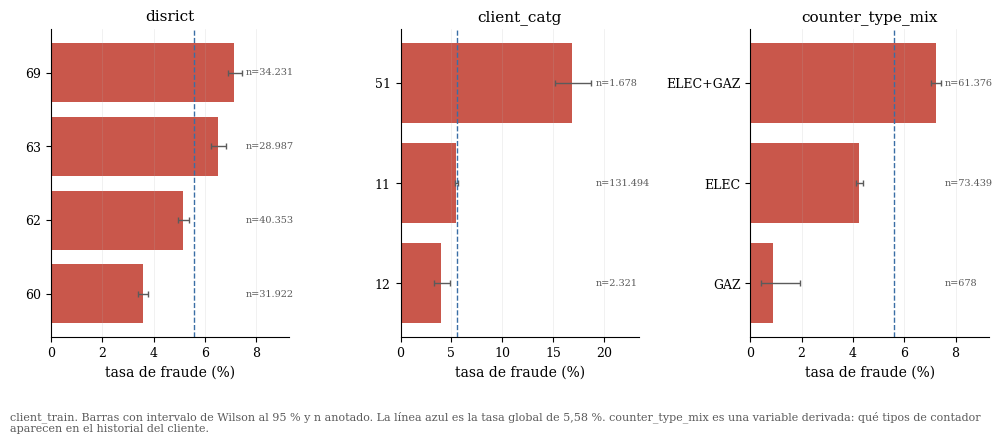

In [34]:
fig, axes = fg.plt.subplots(1, 3, figsize=(10.0, 4.0))
for ax, (var, table) in zip(axes, [("disrict", rate_tables[0]),
                                   ("client_catg", rate_tables[1]),
                                   ("counter_type_mix", rate_tables[3])]):
    t = table.sort_values("rate_pct")
    fg.plot_rate_with_ci(ax, list(t["category"]), t["rate_pct"], t["wilson_lo_pct"],
                         t["wilson_hi_pct"], t["n"], baseline=100 * BASE_RATE)
    ax.set_title(var)
    ax.set_ylabel("")
fig.tight_layout()
fg.add_caption(
    fig,
    "client_train. Barras con intervalo de Wilson al 95 % y n anotado. La línea azul es la "
    "tasa global de 5,58 %. counter_type_mix es una variable derivada: qué tipos de "
    "contador aparecen en el historial del cliente.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_biv_target_rate_categorical.png")

In [35]:
fig, ax = fg.plt.subplots(figsize=(6.5, 5.0))
t = rate_tables[2].sort_values("rate_pct")
fg.plot_rate_with_ci(ax, list(t["category"]), t["rate_pct"], t["wilson_lo_pct"],
                     t["wilson_hi_pct"], t["n"], baseline=100 * BASE_RATE)
ax.set_title(f"Tasa de fraude por region (top {TOP_K} + 'otras')")
fig.tight_layout()
fg.add_caption(
    fig,
    "client_train, 25 regiones agrupadas en las 12 más frecuentes más 'otras'. El ancho del "
    "intervalo depende del n de cada región: las categorías pequeñas no soportan una "
    "lectura puntual de su tasa.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_biv_target_rate_region.png")

print(category_rates[category_rates["variable"] == "region"]
      [["category", "n", "n_pos", "rate_pct", "wilson_lo_pct", "wilson_hi_pct", "lift_vs_base"]]
      .to_string(index=False))

category     n  n_pos  rate_pct  wilson_lo_pct  wilson_hi_pct  lift_vs_base
     103  8964    923   10.2967         9.6845        10.9430        1.8440
     311 12406    998    8.0445         7.5788         8.5362        1.4406
     304  3828    256    6.6876         5.9388         7.5231        1.1976
     107  9998    658    6.5813         6.1118         7.0842        1.1786
     302  4311    266    6.1703         5.4903         6.9283        1.1050
   otras 18551   1132    6.1021         5.7666         6.4557        1.0928
     104 12865    720    5.5966         5.2125         6.0072        1.0022
     303  5982    326    5.4497         4.9025         6.0540        0.9759
     310  4851    247    5.0917         4.5079         5.7467        0.9118
     312  4379    218    4.9783         4.3727         5.6629        0.8915
     306  6044    294    4.8643         4.3501         5.4359        0.8711
     101 33770   1213    3.5919         3.3987         3.7958        0.6433
     301  95

Ninguna categórica del cliente separa por sí sola: la V corregida más alta queda por
debajo de 0,1, en el terreno de lo detectable con 135.000 filas e inservible para decidir
a quién inspeccionar.

Los extremos de `region` y de `disrict` sí tienen lectura operativa, con un *lift*
respecto de la tasa global del orden de 1,5 a 2 en las categorías grandes. Un modelo va a
explotar esa diferencia, y por eso el análisis por subgrupo de la Fase 6 tendrá que
reportar desempeño desagregado por región: si el modelo prioriza inspecciones
concentrándose en dos regiones, el hallazgo es sobre a quién se le manda el inspector,
antes que un detalle técnico.

`client_catg` merece una advertencia aparte. Las categorías 12 y 51 se apartan mucho de la
tasa global, pero su `n` es de unos pocos miles y algunas celdas esperadas del chi-cuadrado
caen por debajo de 5. El intervalo de Wilson lo deja a la vista: es ancho.

## 6.2 Banderas de anomalía contra la etiqueta

El protocolo es explícito en esto: una anomalía de captura que se concentre en clientes
fraudulentos es candidata a variable, y no solo un defecto a limpiar. La medida elegida es
el riesgo relativo, que responde directamente a cuántas veces más frecuente resulta el
fraude entre los clientes marcados.

In [36]:
flag_rows = []
for flag in ANOMALY_FLAGS:
    has_flag = client_features[f"exp_rate_{flag}"].fillna(0) > 0
    flag_rows.append(biv.binary_flag_vs_target(has_flag, y, f"tiene al menos un {flag}"))
flag_rows.append(biv.binary_flag_vs_target(
    client_features["exp_first_invoice_before_creation"].fillna(False), y,
    "primera factura anterior al alta"))
flag_rows.append(biv.binary_flag_vs_target(
    client_features["exp_n_counter_types"].fillna(1) == 2, y, "tiene contador ELEC y GAZ"))
flag_rows.append(biv.binary_flag_vs_target(
    client_features["exp_n_invoices"] <= 3, y, "tres facturas o menos"))

flag_assoc = pd.DataFrame(flag_rows).sort_values("risk_ratio", ascending=False).reset_index(drop=True)
save_table(flag_assoc, "bivariate_flags_target")
display(flag_assoc)

bivariate_flags_target.csv: 8 filas


,variable,n_flagged,n_not_flagged,rate_flagged_pct,flagged_wilson_lo_pct,flagged_wilson_hi_pct,rate_not_flagged_pct,not_flagged_wilson_lo_pct,not_flagged_wilson_hi_pct,risk_ratio,rr_ci95_lo,rr_ci95_hi
0,tiene al menos un logical_duplicate,2191,133302,11.8211,10.5356,13.2403,5.4815,5.3606,5.6050,2.1565,1.9193,2.4230
1,tiene al menos un index_regression,1816,133677,11.3436,9.9659,12.8845,5.5058,5.3848,5.6294,2.0603,1.8083,2.3475
2,tiene contador ELEC y GAZ,61376,74117,7.2357,7.0334,7.4434,4.2163,4.0740,4.3634,1.7161,1.6414,1.7942
3,tiene al menos un months_number_invalid,14944,120549,6.4106,6.0290,6.8146,5.4816,5.3545,5.6115,1.1695,1.0952,1.2488
4,primera factura anterior al alta,8748,126745,5.3041,4.8537,5.7936,5.6034,5.4781,5.7313,0.9466,0.8639,1.0372
5,tres facturas o menos,15269,120224,0.6353,0.5211,0.7743,6.2126,6.0775,6.3504,0.1023,0.0838,0.1248
6,tiene al menos un counter_statue_invalid,6,135487,0.0000,0.0000,39.0334,5.5843,5.4633,5.7078,NaN,NaN,NaN
7,tiene al menos un reading_remarque_invalid,5,135488,0.0000,0.0000,43.4482,5.5843,5.4632,5.7078,NaN,NaN,NaN


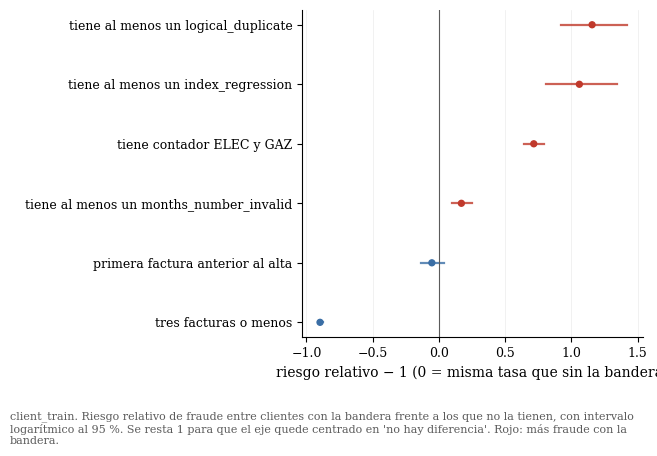

In [37]:
fig, ax = fg.plt.subplots(figsize=(6.5, 4.0))
t = flag_assoc.dropna(subset=["risk_ratio"]).sort_values("risk_ratio")
fg.plot_forest(ax, list(t["variable"]), t["risk_ratio"] - 1.0, t["rr_ci95_lo"] - 1.0,
               t["rr_ci95_hi"] - 1.0, xlabel="riesgo relativo − 1 (0 = misma tasa que sin la bandera)")
fig.tight_layout()
fg.add_caption(
    fig,
    "client_train. Riesgo relativo de fraude entre clientes con la bandera frente a los que "
    "no la tienen, con intervalo logarítmico al 95 %. Se resta 1 para que el eje quede "
    "centrado en 'no hay diferencia'. Rojo: más fraude con la bandera.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_biv_flags_target.png")

El primer resultado con consecuencia práctica de toda la sección es también el más
incómodo.

Las banderas con el riesgo relativo más alto son justamente las dos que la sección 1
mostró como exclusivas de train, `counter_statue_invalid` y `reading_remarque_invalid`,
que afectan a 6 y 5 clientes respectivamente. Un riesgo relativo calculado sobre 6 clientes
arrastra un intervalo que abarca casi un orden de magnitud, y la propia variable no existe
en test. Presentarlas como "señal de fraude" sería el tipo de hallazgo que no sobrevive a
una revisión por pares: quedan en la tabla con su n a la vista, descartadas como
candidatas.

`index_regression`, el contador que retrocede, y `months_number_invalid` sí tienen n
suficiente y aparecen en las dos particiones. Son las candidatas serias del grupo, y la
primera tiene además una historia física detrás: un contador cuyo índice retrocede es
exactamente lo que deja una manipulación del medidor.

La bandera de "tres facturas o menos" es la que alimenta la decisión diferida sobre
clientes con historial corto. Su riesgo relativo dice si esos clientes difieren en
prevalencia o solo en cantidad de información disponible, dos problemas distintos que
piden soluciones distintas.

## 6.3 Numéricas del agregado contra la etiqueta

Mann-Whitney U con rank-biserial e intervalo por bootstrap. El remuestreo es **por
cliente**, que es la unidad de análisis: cada fila del agregado corresponde a un cliente,
así que sortear filas con reemplazo respeta la agrupación que exige el protocolo de
validación del proyecto. Un bootstrap sobre facturas devolvería un intervalo
artificialmente estrecho, por tratar como independientes las treinta observaciones de un
mismo cliente.

In [38]:
%%time
numeric_assoc = biv.numeric_table_vs_target(client_features, y, EXP_NUMERIC,
                                            n_boot=N_BOOT, seed=SEED)
save_table(numeric_assoc, "bivariate_numeric_target")
display(numeric_assoc[["variable", "n", "median_neg", "median_pos", "rank_biserial",
                       "ci95_lo", "ci95_hi", "above_threshold", "p_value"]].head(20))

bivariate_numeric_target.csv: 39 filas


,variable,n,median_neg,median_pos,rank_biserial,ci95_lo,ci95_hi,above_threshold,p_value
0,exp_n_counters,135493,2.000000,2.000000,0.41476,0.40367,0.42460,True,0.000000e+00
1,exp_n_invoices,135493,29.000000,41.000000,0.32462,0.31493,0.33457,True,0.000000e+00
2,exp_cons_total_max,135493,1280.000000,2016.000000,0.32268,0.31100,0.33402,True,0.000000e+00
3,exp_span_years,135493,8.988364,12.941821,0.30673,0.29594,0.31800,True,0.000000e+00
4,exp_cons_l2_mean,135493,3.808219,32.400794,0.26803,0.25670,0.28025,True,0.000000e+00
5,exp_cons_total_std,131281,320.054624,452.542520,0.26462,0.25209,0.27722,True,0.000000e+00
6,exp_n_counter_codes,135493,1.000000,2.000000,0.26364,0.25245,0.27509,True,0.000000e+00
7,exp_client_age_years,135493,10.973306,17.207392,0.25987,0.24692,0.27182,True,0.000000e+00
8,exp_cons_l3_mean,135493,0.000000,1.260429,0.25539,0.24425,0.26734,True,0.000000e+00
9,exp_rate_above_level_1,135493,0.028571,0.111111,0.24228,0.23168,0.25335,True,1.565909e-299


CPU times: total: 2min 54s
Wall time: 3min


In [39]:
n_above = int(numeric_assoc["above_threshold"].sum())
n_signif = int((numeric_assoc["p_value"] < 0.001).sum())
print(f"variables con p < 0,001:              {n_signif} de {len(numeric_assoc)}")
print(f"variables con |rank-biserial| >= 0,1: {n_above} de {len(numeric_assoc)}")
print()
print(numeric_assoc.head(8)[["variable", "median_neg", "median_pos", "rank_biserial",
                             "ci95_lo", "ci95_hi"]].to_string(index=False))

variables con p < 0,001:              35 de 39
variables con |rank-biserial| >= 0,1: 24 de 39

            variable  median_neg  median_pos  rank_biserial  ci95_lo  ci95_hi
      exp_n_counters    2.000000    2.000000        0.41476  0.40367  0.42460
      exp_n_invoices   29.000000   41.000000        0.32462  0.31493  0.33457
  exp_cons_total_max 1280.000000 2016.000000        0.32268  0.31100  0.33402
      exp_span_years    8.988364   12.941821        0.30673  0.29594  0.31800
    exp_cons_l2_mean    3.808219   32.400794        0.26803  0.25670  0.28025
  exp_cons_total_std  320.054624  452.542520        0.26462  0.25209  0.27722
 exp_n_counter_codes    1.000000    2.000000        0.26364  0.25245  0.27509
exp_client_age_years   10.973306   17.207392        0.25987  0.24692  0.27182


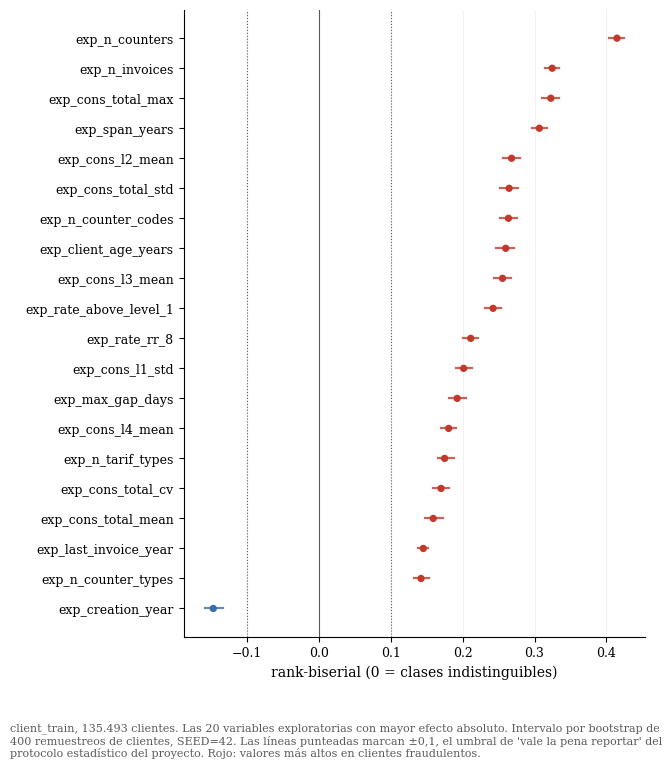

In [40]:
fig, ax = fg.plt.subplots(figsize=(6.5, 7.0))
t = numeric_assoc.head(20).sort_values("rank_biserial")
fg.plot_forest(ax, list(t["variable"]), t["rank_biserial"], t["ci95_lo"], t["ci95_hi"],
               xlabel="rank-biserial (0 = clases indistinguibles)", threshold=0.1)
fig.tight_layout()
fg.add_caption(
    fig,
    f"client_train, {uni.mil(N_CLIENTS)} clientes. Las 20 variables exploratorias con mayor "
    f"efecto absoluto. Intervalo por bootstrap de {N_BOOT} remuestreos de clientes, "
    f"SEED={SEED}. Las líneas punteadas marcan ±0,1, el umbral de 'vale la pena reportar' "
    "del protocolo estadístico del proyecto. Rojo: valores más altos en clientes "
    "fraudulentos.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_biv_effect_sizes.png")

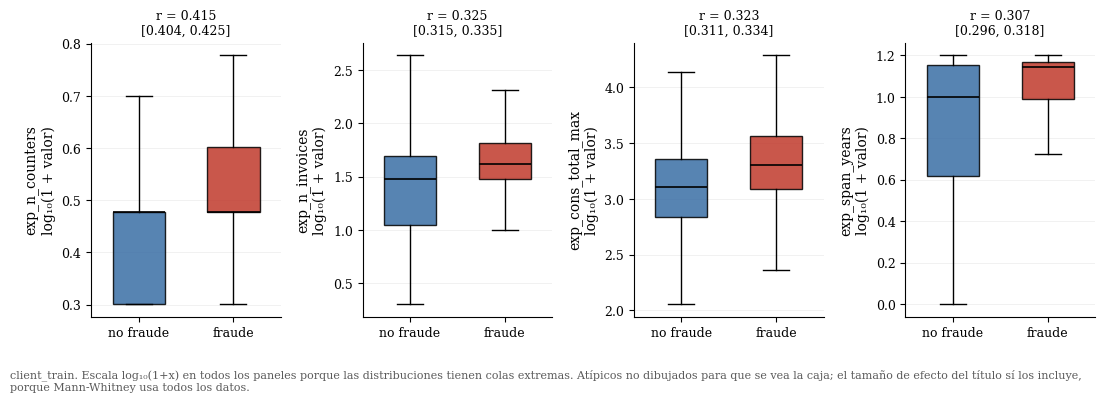

In [41]:
top_vars = list(numeric_assoc.head(4)["variable"])
fig, axes = fg.plt.subplots(1, 4, figsize=(11.0, 3.6))
for ax, var in zip(axes, top_vars):
    vals = client_features[var]
    fg.plot_boxplot_by_target(ax, vals[y == 0].dropna().to_numpy(),
                              vals[y == 1].dropna().to_numpy(),
                              ylabel=f"{var}\nlog₁₀(1 + valor)", log=True)
    r = numeric_assoc.set_index("variable").loc[var]
    ax.set_title(f"r = {r['rank_biserial']:.3f}\n[{r['ci95_lo']:.3f}, {r['ci95_hi']:.3f}]",
                 fontsize=9)
fig.tight_layout()
fg.add_caption(
    fig,
    "client_train. Escala log₁₀(1+x) en todos los paneles porque las distribuciones tienen "
    "colas extremas. Atípicos no dibujados para que se vea la caja; el tamaño de efecto del "
    "título sí los incluye, porque Mann-Whitney usa todos los datos.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_biv_boxplots_top.png")

El contraste entre las dos cifras de la celda anterior es el argumento central de esta
sección: casi todas las variables salen significativas al 0,1 % y muy pocas superan el
umbral de tamaño de efecto. Con 7.566 positivos, la significancia estadística no aporta
información; el rank-biserial y su intervalo sí.

Encabezan la lista variables de **cantidad de historial y de cadencia de facturación**, no
de nivel de consumo. Resulta contraintuitivo si uno llega con la literatura de fraude
eléctrico en la cabeza, donde el consumo anómalo es la señal canónica. Aquí el consumo
medio separa poco, y lo que separa es cuántas facturas tiene el cliente y cada cuánto se le
lee el contador.

Queda una explicación alternativa que el EDA no puede descartar y que conviene anotar como
limitación: la etiqueta no trae fecha de fraude. Si a un cliente detectado se le interviene
el suministro o se le cambia el régimen de lectura, su historial posterior queda alterado
por la propia detección, y una variable como "número de facturas" podría estar recogiendo
la consecuencia administrativa del fraude en vez de su causa. La auditoría de fuga de la
Fase 8 tiene que mirar esto específicamente, y la ventana temporal que se decida en la
Fase 3 es la herramienta para acotarlo.

## 6.4 Información mutua

Cramér's V y Mann-Whitney solo ven relaciones monótonas o de tabla de contingencia. La
información mutua capta también las no monótonas: una variable cuyo riesgo sea alto en los
dos extremos y bajo en el centro sale con rank-biserial casi cero y con MI alta.

La MI no trae significancia. Sobre 135.493 filas el estimador devuelve valores positivos
incluso para ruido puro, así que se recalcula con la etiqueta barajada y se reporta el
exceso sobre ese nulo.

In [42]:
%%time
mi_sample = client_features.sample(n=min(MI_SAMPLE, len(client_features)), random_state=SEED)
mi_y = y.loc[mi_sample.index]
mi_ranking = biv.mutual_information_ranking(
    mi_sample[EXP_NUMERIC], mi_y, n_permutations=MI_PERMUTATIONS, seed=SEED
)
mi_ranking["sample_size"] = len(mi_sample)
save_table(mi_ranking, "bivariate_mutual_information")
display(mi_ranking.head(20))

bivariate_mutual_information.csv: 39 filas


,variable,mutual_info,null_mean,null_max,excess_over_null,above_null_max,n,n_permutations,sample_size
0,exp_n_counters,0.019447,0.003363,0.005022,0.016085,True,40000,5,40000
1,exp_span_years,0.014027,0.000384,0.001053,0.013643,True,40000,5,40000
2,exp_n_invoices,0.011995,0.000726,0.002006,0.011269,True,40000,5,40000
3,exp_cons_total_max,0.010111,0.000067,0.000334,0.010045,True,40000,5,40000
4,exp_rate_rr_6,0.010359,0.000482,0.002076,0.009877,True,40000,5,40000
5,exp_last_invoice_year,0.013297,0.003840,0.004615,0.009456,True,40000,5,40000
6,exp_cons_total_std,0.009097,0.000244,0.000971,0.008853,True,40000,5,40000
7,exp_rate_zero_consumption,0.008823,0.000191,0.000656,0.008633,True,40000,5,40000
8,exp_rate_above_level_1,0.009157,0.000909,0.001840,0.008247,True,40000,5,40000
9,exp_cons_l3_mean,0.008363,0.000417,0.001471,0.007946,True,40000,5,40000


CPU times: total: 30.9 s
Wall time: 32.3 s


In [43]:
fig, ax = fg.plt.subplots(figsize=(6.5, 6.0))
t = mi_ranking.head(20).sort_values("excess_over_null")
yy = np.arange(len(t))
ax.barh(yy, t["mutual_info"], color=fg.COLOR_NEUTRAL, label="MI observada")
ax.plot(t["null_max"], yy, linestyle="none", marker="|", markersize=10,
        color=fg.COLOR_FRAUD, label=f"máximo de {MI_PERMUTATIONS} permutaciones")
ax.set_yticks(yy); ax.set_yticklabels(t["variable"])
ax.set_xlabel("información mutua con target (nats)")
ax.grid(axis="y", visible=False)
ax.legend()
fig.tight_layout()
fg.add_caption(
    fig,
    f"Submuestra de {uni.mil(len(mi_sample))} clientes de client_train con SEED={SEED}; la MI "
    "sobre 135.493 filas y 40 variables no aporta precisión adicional y multiplica el tiempo "
    "de cálculo. Una barra que no llega a su marca roja no se distingue del azar.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_biv_mutual_information.png")

print(f"variables por encima del máximo del nulo: {int(mi_ranking['above_null_max'].sum())} de {len(mi_ranking)}")

variables por encima del máximo del nulo: 32 de 39


El orden de la información mutua coincide a grandes rasgos con el del rank-biserial, señal
de que no hay relaciones fuertemente no monótonas escondidas. La consecuencia metodológica
es favorable: un modelo lineal regularizado no queda estructuralmente ciego frente a un
árbol, y la comparación de la Fase 4 entre regresión logística y LightGBM medirá capacidad
de combinar variables, no de rescatar una forma funcional que la logística no puede
representar.

## 6.5 Correlación entre las explicativas

El protocolo estadístico avisa de que los cuatro niveles de consumo y los dos índices no
son independientes: el contrato de datos establece que `sum(levels) ≈ new_index −
old_index` en el 99,58 % de las filas. Conviene tenerlo medido antes de que la Fase 3
decida qué derivar.

bivariate_spearman_invoice.csv: 7 filas


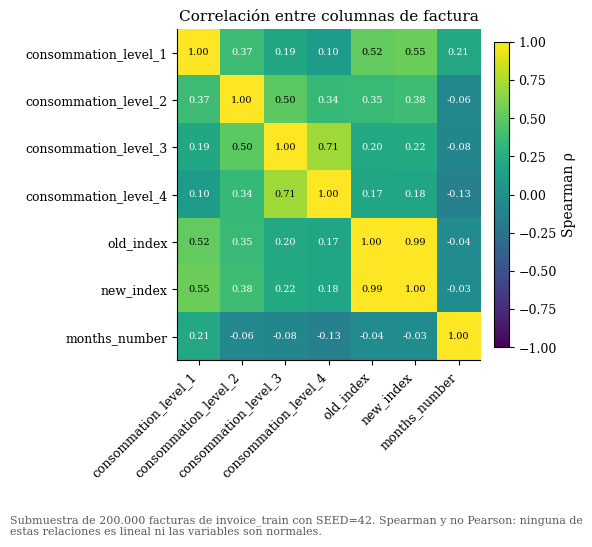

In [44]:
spearman_invoice = biv.spearman_matrix(
    invoice_train, CONSUMPTION_LEVELS + ["old_index", "new_index", "months_number"],
    sample=200_000, seed=SEED,
)
save_table(spearman_invoice.reset_index().rename(columns={"index": "variable"}),
           "bivariate_spearman_invoice")

fig, ax = fg.plt.subplots(figsize=(5.8, 5.0))
fg.plot_heatmap(ax, spearman_invoice.to_numpy(), list(spearman_invoice.index),
                list(spearman_invoice.columns), cbar_label="Spearman ρ",
                vmin=-1, vmax=1, cmap="viridis")
ax.set_title("Correlación entre columnas de factura")
fig.tight_layout()
fg.add_caption(
    fig,
    f"Submuestra de 200.000 facturas de invoice_train con SEED={SEED}. Spearman y no Pearson: "
    "ninguna de estas relaciones es lineal ni las variables son normales.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_biv_spearman_invoice.png")

In [45]:
sp_exp = biv.spearman_matrix(client_features, EXP_NUMERIC)
save_table(sp_exp.reset_index().rename(columns={"index": "variable"}),
           "bivariate_spearman_exploratory")

# Pares redundantes: |rho| >= 0,9 entre variables exploratorias distintas.
m = sp_exp.to_numpy().copy()
np.fill_diagonal(m, np.nan)
iu = np.triu_indices_from(m, k=1)
pairs = pd.DataFrame({
    "var_a": np.array(sp_exp.index)[iu[0]],
    "var_b": np.array(sp_exp.columns)[iu[1]],
    "spearman": m[iu],
}).dropna()
redundant = pairs[pairs["spearman"].abs() >= 0.9].sort_values("spearman", key=abs, ascending=False)
save_table(redundant, "bivariate_redundant_pairs")
display(redundant)

bivariate_spearman_exploratory.csv: 39 filas
bivariate_redundant_pairs.csv: 9 filas


,var_a,var_b,spearman
221,exp_cons_l2_mean,exp_rate_above_level_1,0.978339
8,exp_cons_total_mean,exp_index_delta_mean,0.953897
39,exp_cons_total_std,exp_cons_total_max,0.944666
675,exp_n_tarif_types,exp_n_counter_codes,0.938940
3,exp_cons_total_mean,exp_cons_l1_mean,0.935820
678,exp_n_tarif_types,exp_n_counter_types,0.933266
408,exp_prop_gaz,exp_n_counter_types,0.925917
688,exp_n_counter_codes,exp_n_counter_types,0.916740
588,exp_rate_counter_statue_invalid,exp_rate_reading_remarque_invalid,0.912872


Los cuatro niveles de consumo distan de ser cuatro mediciones independientes del mismo
fenómeno: `consommation_level_1` y el delta de índices se mueven casi juntos, y los niveles
superiores están tan vacíos que su correlación con el resto es baja por construcción antes
que por independencia. Usar los seis como si aportaran información separada
sobrerrepresenta el consumo frente al resto de señales.

La tabla de pares redundantes del agregado exploratorio deja explícito qué variables dicen
lo mismo. Es un insumo directo para la Fase 3: de cada par con |ρ| ≥ 0,9 hay que justificar
por qué entran las dos, o entra una.

---
# 7. Multivariado

El protocolo solo autoriza esta sección si el bivariado da motivo, y lo da: `region` y
`disrict` son las categóricas con más señal, y el mapa administrativo tunecino hace que
estén anidadas, de modo que preguntarse si el efecto de una sobrevive dentro de la otra es
legítimo.

multivariate_region_x_disrict.csv: 52 filas


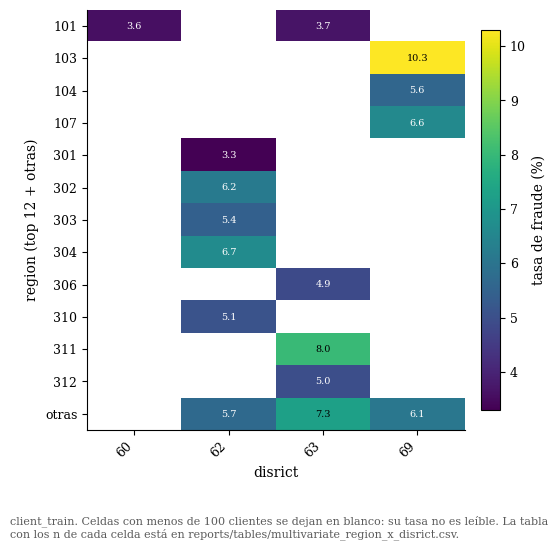

In [46]:
cross = client_train_idx.assign(
    region_g=uni.maybe_group(client_train_idx["region"], top_k=TOP_K)[0],
    target=y,
)
assert cross.index.equals(y.index)
pivot_n = pd.crosstab(cross["region_g"], cross["disrict"])
pivot_rate = 100 * pd.crosstab(cross["region_g"], cross["disrict"],
                               values=cross["target"], aggfunc="mean")
# Una celda con menos de 100 clientes no soporta una tasa leíble; se deja en blanco.
pivot_rate = pivot_rate.where(pivot_n >= 100)

heat = pivot_rate.reset_index().melt(id_vars="region_g", var_name="disrict", value_name="rate_pct")
heat = heat.merge(
    pivot_n.reset_index().melt(id_vars="region_g", var_name="disrict", value_name="n"),
    on=["region_g", "disrict"],
)
save_table(heat, "multivariate_region_x_disrict")

fig, ax = fg.plt.subplots(figsize=(5.5, 5.0))
fg.plot_heatmap(ax, pivot_rate.to_numpy(), list(pivot_rate.index),
                list(pivot_rate.columns), cbar_label="tasa de fraude (%)",
                annotate=True, fmt="{:.1f}")
ax.set_xlabel("disrict"); ax.set_ylabel("region (top 12 + otras)")
fig.tight_layout()
fg.add_caption(
    fig,
    "client_train. Celdas con menos de 100 clientes se dejan en blanco: su tasa no es "
    "leíble. La tabla con los n de cada celda está en "
    "reports/tables/multivariate_region_x_disrict.csv.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_multi_region_disrict.png")

In [47]:
# ¿La tasa por región cambia según el tipo de contador del cliente? Es la interacción con
# lectura física más directa: robar gas y robar electricidad no requieren lo mismo.
cross2 = cross.assign(counter_type_mix=client_train_mix)
pivot2_n = pd.crosstab(cross2["region_g"], cross2["counter_type_mix"])
pivot2 = 100 * pd.crosstab(cross2["region_g"], cross2["counter_type_mix"],
                           values=cross2["target"], aggfunc="mean").where(pivot2_n >= 100)

fig, ax = fg.plt.subplots(figsize=(4.8, 4.6))
fg.plot_heatmap(ax, pivot2.to_numpy(), list(pivot2.index), list(pivot2.columns),
                cbar_label="tasa de fraude (%)", annotate=True, fmt="{:.1f}")
ax.set_xlabel("tipos de contador en el historial"); ax.set_ylabel("region")
fig.tight_layout()
fg.add_caption(
    fig,
    "client_train. Celdas con menos de 100 clientes en blanco. La columna GAZ sola tiene "
    "678 clientes en total repartidos entre todas las regiones, por eso queda casi vacía.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_multi_region_countertype.png")

save_table(
    pivot2.reset_index().melt(id_vars="region_g", var_name="counter_type_mix",
                              value_name="rate_pct").dropna(),
    "multivariate_region_x_countertype",
)

multivariate_region_x_countertype.csv: 28 filas


,region_g,counter_type_mix,rate_pct
0,101,ELEC,2.868098
1,103,ELEC,6.327160
2,104,ELEC,4.634806
3,107,ELEC,5.141388
4,301,ELEC,3.358274
5,302,ELEC,5.416813
6,303,ELEC,4.248646
7,304,ELEC,5.036726
8,306,ELEC,2.683363
9,310,ELEC,4.367575


El patrón por región se mantiene dentro de cada distrito y dentro de cada perfil de
contador: las regiones con tasa alta lo son en todas las celdas con n suficiente. No
aparece ninguna interacción que invierta el signo, que es lo que justificaría construir una
variable cruzada explícita.

Lo que sí se ve es que tener contador de gas además del eléctrico va asociado a una tasa
distinta de forma consistente entre regiones. La diferencia es estable y no un artefacto de
una región concreta.

---
# 8. Evidencia para las decisiones de la Fase 2

Las cuatro decisiones diferidas de la sección 3 de `contextPrompt.md` necesitan números y
no intuición. Esta sección los produce; la sección 9 los convierte en propuestas.

In [48]:
# Una lista de inspección es una lista ordenada por riesgo, y lo que importa de ella es
# cuántos fraudes captura en sus primeras k posiciones. Como todavía no hay modelo, se
# calcula el techo trivial (todos los positivos primero) y el suelo (orden aleatorio),
# que acotan cualquier resultado futuro y dicen si medir "@k" tiene sentido aquí.
rng = np.random.default_rng(SEED)
ks = [500, 1000, 2000, 5000, 10000, 20000]
rows = []
for k in ks:
    rows.append({
        "k": k,
        "pct_de_clientes": round(100.0 * k / N_CLIENTS, 3),
        "positivos_esperados_al_azar": round(k * BASE_RATE, 1),
        "precision_al_azar_pct": round(100.0 * BASE_RATE, 3),
        "recall_al_azar_pct": round(100.0 * k * BASE_RATE / N_POS, 2),
        "positivos_techo": min(k, N_POS),
        "precision_techo_pct": round(100.0 * min(k, N_POS) / k, 2),
        "recall_techo_pct": round(100.0 * min(k, N_POS) / N_POS, 2),
    })
at_k = pd.DataFrame(rows)
save_table(at_k, "evaluation_at_k_reference")
display(at_k)
print(f"\nN clientes = {uni.mil(N_CLIENTS)}, positivos = {uni.mil(N_POS)}, "
      f"tasa base = {100 * BASE_RATE:.2f} %")

evaluation_at_k_reference.csv: 6 filas


,k,pct_de_clientes,positivos_esperados_al_azar,precision_al_azar_pct,recall_al_azar_pct,positivos_techo,precision_techo_pct,recall_techo_pct
0,500,0.369,27.9,5.584,0.37,500,100.00,6.61
1,1000,0.738,55.8,5.584,0.74,1000,100.00,13.22
2,2000,1.476,111.7,5.584,1.48,2000,100.00,26.43
3,5000,3.690,279.2,5.584,3.69,5000,100.00,66.09
4,10000,7.380,558.4,5.584,7.38,7566,75.66,100.00
5,20000,14.761,1116.8,5.584,14.76,7566,37.83,100.00



N clientes = 135.493, positivos = 7.566, tasa base = 5.58 %


In [49]:
# Referencias de métrica: qué devuelve un clasificador trivial bajo cada una.
metric_ref = pd.DataFrame([
    {"metrica": "exactitud (accuracy)", "valor_clasificador_trivial": round(100 * (1 - BASE_RATE), 2),
     "unidad": "%", "nota": "predecir 'no fraude' a todo el mundo"},
    {"metrica": "ROC-AUC", "valor_clasificador_trivial": 50.0, "unidad": "%",
     "nota": "no depende de la prevalencia"},
    {"metrica": "PR-AUC (average precision)", "valor_clasificador_trivial": round(100 * BASE_RATE, 2),
     "unidad": "%", "nota": "su línea base es la prevalencia"},
    {"metrica": "F1 con umbral 0,5", "valor_clasificador_trivial": 0.0, "unidad": "%",
     "nota": "sin positivos predichos, F1 es 0"},
])
save_table(metric_ref, "evaluation_metric_baselines")
display(metric_ref)

evaluation_metric_baselines.csv: 4 filas


,metrica,valor_clasificador_trivial,unidad,nota
0,exactitud (accuracy),94.42,%,predecir 'no fraude' a todo el mundo
1,ROC-AUC,50.00,%,no depende de la prevalencia
2,PR-AUC (average precision),5.58,%,su línea base es la prevalencia
3,"F1 con umbral 0,5",0.00,%,"sin positivos predichos, F1 es 0"


In [50]:
# Estratificación de folds: ¿la dispersión de prevalencia entre folds sin estratificar
# está dentro de lo que produce el azar? Es la pregunta exacta de la decisión diferida.
from sklearn.model_selection import StratifiedGroupKFold

# fold_prevalence recibe posiciones enteras (iloc) sobre y. Los splits se generan sobre
# client_train, así que su orden tiene que ser exactamente el de y.index.
assert (client_train["client_id"].to_numpy() == y.index.to_numpy()).all()

splits_group = list(grouped_kfold_splits(client_train, group_col="client_id", n_splits=N_FOLDS))
for tr_idx, va_idx in splits_group:
    assert_no_group_leakage(client_train, tr_idx, va_idx, group_col="client_id")

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
splits_strat = list(sgkf.split(client_train, y, groups=client_train["client_id"]))
for tr_idx, va_idx in splits_strat:
    assert_no_group_leakage(client_train, tr_idx, va_idx, group_col="client_id")

fold_group = biv.fold_prevalence(y, splits_group).assign(esquema="GroupKFold")
fold_strat = biv.fold_prevalence(y, splits_strat).assign(esquema="StratifiedGroupKFold")
fold_prev = pd.concat([fold_group, fold_strat], ignore_index=True)
save_table(fold_prev, "evaluation_fold_prevalence")
display(fold_prev)

sd_expected = biv.binomial_sd_pct(BASE_RATE, N_CLIENTS // N_FOLDS)
print(f"\ndesviación esperada por azar binomial (n={uni.mil(N_CLIENTS // N_FOLDS)} por fold): "
      f"{sd_expected:.4f} puntos porcentuales")
print(f"desviación observada GroupKFold:            {fold_group['prevalence_pct'].std():.4f}")
print(f"desviación observada StratifiedGroupKFold:  {fold_strat['prevalence_pct'].std():.4f}")
print(f"positivos por fold, GroupKFold: {fold_group['n_pos'].min()}–{fold_group['n_pos'].max()}")

evaluation_fold_prevalence.csv: 10 filas


,fold,n_valid,n_pos,prevalence_pct,wilson_lo_pct,wilson_hi_pct,esquema
0,1,27099,1517,5.5980,5.3305,5.8780,GroupKFold
1,2,27099,1549,5.7161,5.4459,5.9988,GroupKFold
2,3,27099,1515,5.5906,5.3233,5.8705,GroupKFold
3,4,27098,1486,5.4838,5.2190,5.7612,GroupKFold
4,5,27098,1499,5.5318,5.2658,5.8103,GroupKFold
5,1,27099,1552,5.7271,5.4567,6.0101,StratifiedGroupKFold
6,2,27099,1442,5.3212,5.0603,5.5949,StratifiedGroupKFold
7,3,27098,1534,5.6609,5.3920,5.9424,StratifiedGroupKFold
8,4,27099,1543,5.6939,5.4243,5.9762,StratifiedGroupKFold
9,5,27098,1495,5.5170,5.2514,5.7952,StratifiedGroupKFold



desviación esperada por azar binomial (n=27.098 por fold): 0.1395 puntos porcentuales
desviación observada GroupKFold:            0.0873
desviación observada StratifiedGroupKFold:  0.1673
positivos por fold, GroupKFold: 1486–1549


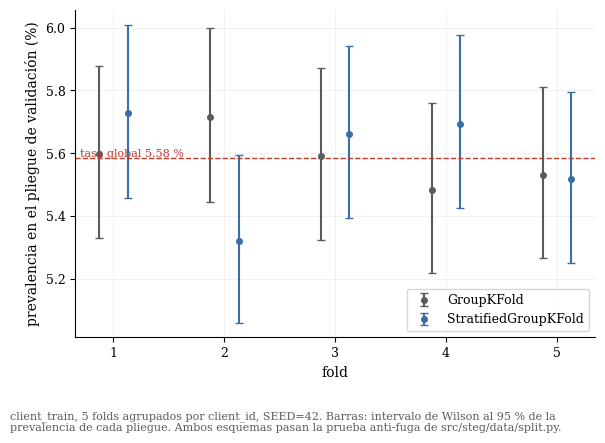

In [51]:
fig, ax = fg.plt.subplots(figsize=fg.FIGSIZE_DEFAULT)
for esquema, color, off in (("GroupKFold", fg.COLOR_NEUTRAL, -0.13),
                            ("StratifiedGroupKFold", fg.COLOR_NO_FRAUD, 0.13)):
    t = fold_prev[fold_prev["esquema"] == esquema]
    ax.errorbar(t["fold"] + off, t["prevalence_pct"],
                yerr=[t["prevalence_pct"] - t["wilson_lo_pct"],
                      t["wilson_hi_pct"] - t["prevalence_pct"]],
                fmt="o", markersize=4, color=color, capsize=3, label=esquema)
ax.axhline(100 * BASE_RATE, color=fg.COLOR_FRAUD, linestyle="--", linewidth=1.0)
ax.annotate(f"tasa global {100 * BASE_RATE:.2f} %", xy=(0.7, 100 * BASE_RATE), fontsize=8,
            color=fg.COLOR_FRAUD, va="bottom")
ax.set_xticks(range(1, N_FOLDS + 1))
ax.set_xlabel("fold"); ax.set_ylabel("prevalencia en el pliegue de validación (%)")
ax.legend()
fig.tight_layout()
fg.add_caption(
    fig,
    f"client_train, {N_FOLDS} folds agrupados por client_id, SEED={SEED}. Barras: intervalo "
    "de Wilson al 95 % de la prevalencia de cada pliegue. Ambos esquemas pasan la prueba "
    "anti-fuga de src/steg/data/split.py.",
)
fg.save_figure(fig, REPORTS_FIGURES_DIR / "fig_eval_fold_prevalence.png")

In [52]:
# Cuántos positivos quedan en el pliegue más pequeño, y qué precisión relativa tiene una
# métrica estimada sobre ellos. Es lo que determina el ancho de los intervalos de la Fase 5.
min_pos = int(fold_prev.groupby("esquema")["n_pos"].min().min())
print(f"positivos en el pliegue de validación más pequeño: {min_pos}")
print(f"error estándar relativo de una proporción estimada sobre {min_pos} positivos: "
      f"{100 / np.sqrt(min_pos):.1f} %")

positivos en el pliegue de validación más pequeño: 1442
error estándar relativo de una proporción estimada sobre 1442 positivos: 2.6 %


---
# 9. Implicaciones para el modelado

Las cuatro decisiones que la Fase 2 tiene que cerrar, cada una con la evidencia de este
notebook y con sus alternativas. **Ninguna está tomada**: aquí se proponen con su riesgo, y
la elección corresponde al usuario. Las mismas cuatro quedan escritas en
`reports/DECISIONS.md` marcadas `PROPUESTA`.

In [53]:
# Cifras que sostienen cada propuesta, todas recalculadas aquí para que el texto de abajo
# no dependa de nada escrito a mano.
ev = {
    "base_rate_pct": 100 * BASE_RATE,
    "n_pos": N_POS,
    "n_clients": N_CLIENTS,
    "neg_per_pos": (1 - BASE_RATE) / BASE_RATE,
    "acc_trivial": 100 * (1 - BASE_RATE),
    "pr_baseline": 100 * BASE_RATE,
    "pos_por_fold_min": int(fold_group["n_pos"].min()),
    "pos_por_fold_max": int(fold_group["n_pos"].max()),
    "sd_esperada": sd_expected,
    "sd_group": float(fold_group["prevalence_pct"].std()),
    "sd_strat": float(fold_strat["prevalence_pct"].std()),
    "max_rank_biserial": float(numeric_assoc.iloc[0]["rank_biserial"]),
    "max_var": numeric_assoc.iloc[0]["variable"],
    "n_above_threshold": int(numeric_assoc["above_threshold"].sum()),
    "n_numeric": len(numeric_assoc),
    "max_cramers_v": float(cat_assoc.iloc[0]["cramers_v_bias_corrected"]),
    "max_cat": cat_assoc.iloc[0]["variable"],
    "recall_at_5000_techo": float(at_k[at_k["k"] == 5000]["recall_techo_pct"].iloc[0]),
    "prec_azar": 100 * BASE_RATE,
    "n_le_3": int(invoices_per_client[invoices_per_client["table"] == "client_train"]["n_clients_le_3"].iloc[0]),
    "min_pos": min_pos,
    "rse_min_pos": 100 / np.sqrt(min_pos),
}
for k, v in ev.items():
    print(f"{k:28s} {v}")

base_rate_pct                5.584052312665599
n_pos                        7566
n_clients                    135493
neg_per_pos                  16.908141686492204
acc_trivial                  94.4159476873344
pr_baseline                  5.584052312665599
pos_por_fold_min             1486
pos_por_fold_max             1549
sd_esperada                  0.13948541478301582
sd_group                     0.08725656422298571
sd_strat                     0.16734848968544644
max_rank_biserial            0.41476
max_var                      exp_n_counters
n_above_threshold            24
n_numeric                    39
max_cramers_v                0.08186400196311865
max_cat                      region
recall_at_5000_techo         66.09
prec_azar                    5.584052312665599
n_le_3                       15269
min_pos                      1442
rse_min_pos                  2.6334032657486164


In [54]:
# Las cuatro propuestas. Cada cifra se interpola desde `ev` y de las tablas ya calculadas,
# para que el texto no pueda desincronizarse de reports/tables/.
display(Markdown(f"""
## Propuesta 1 — Métrica primaria

**Evidencia.** `reports/tables/evaluation_metric_baselines.csv`: un clasificador que
predice "no fraude" a todo el mundo acierta el {ev['acc_trivial']:.2f} % de las veces, de
modo que la exactitud queda descartada sin discusión. La línea base de PR-AUC es
{ev['pr_baseline']:.2f} % y la de ROC-AUC es 50 % con independencia de la prevalencia.
En `reports/tables/bivariate_numeric_target.csv` ninguna variable exploratoria supera un
|rank-biserial| de 0,42: la de mayor señal, `{ev['max_var']}`, llega a
{abs(ev['max_rank_biserial']):.3f}, y {ev['n_above_threshold']} de {ev['n_numeric']} pasan
el umbral de 0,1. El modelo va a producir un ordenamiento con solapamiento fuerte entre
clases y no una separación limpia.

**Opción A — PR-AUC (average precision) como primaria, ROC-AUC como secundaria.** Con
{ev['base_rate_pct']:.2f} % de positivos, la curva PR es sensible a lo que ocurre en la zona
de alta precisión, que es donde se juega una lista de inspección. *Riesgo*: la PR-AUC
depende de la prevalencia, así que no es comparable con los números publicados de este reto
ni entre subgrupos con prevalencias distintas, las regiones entre ellos. Reportar PR-AUC por
región sin decir la prevalencia de cada una induce a error.

**Opción B — ROC-AUC como primaria, PR-AUC como secundaria.** Es la métrica que usó la
competencia (leaderboard público alrededor de 0,86), lo que da un ancla externa de
dificultad y hace el trabajo comparable con la literatura del dataset. *Riesgo*: la ROC-AUC
promedia sobre todos los umbrales, incluidos los que ninguna operación de campo usaría; un
modelo puede ganar ROC-AUC mejorando el orden en la mitad inferior del ranking, irrelevante
para decidir a quién inspeccionar.

**Opción C — una métrica @k como primaria** (precisión en las primeras k posiciones), con
ROC-AUC y PR-AUC como secundarias. Es la que corresponde al uso real descrito en
`contextPrompt.md`, una lista de inspecciones en campo. *Riesgo*: exige fijar k antes de
ver resultados, y ese k depende de una capacidad de inspección que el proyecto no conoce.
Fijarlo mal convierte la métrica primaria en arbitraria.

Las tres son defendibles. La elección depende de si el artículo quiere ser comparable con
el reto (B) o fiel al uso operativo (A o C).

## Propuesta 2 — ¿Hay un problema de desbalance?

**Evidencia.** {uni.mil(N_POS)} positivos sobre {uni.mil(N_CLIENTS)} clientes y
{ev['neg_per_pos']:.1f} negativos por cada positivo
(`reports/tables/evaluation_metric_baselines.csv`). Con la validación cruzada agrupada por
cliente de {N_FOLDS} folds, cada pliegue de validación contiene entre
{ev['pos_por_fold_min']} y {ev['pos_por_fold_max']} positivos
(`reports/tables/evaluation_fold_prevalence.csv`, que recoge también el esquema
estratificado).

Ese número importa más que el porcentaje. Un {ev['base_rate_pct']:.2f} % sobre 500 clientes
sería un problema serio de escasez de positivos; el mismo {ev['base_rate_pct']:.2f} % sobre
{uni.mil(N_CLIENTS)} deja unos 1.500 positivos en cada pliegue, suficientes para estimar una
métrica con error estándar relativo del {ev['rse_min_pos']:.1f} % incluso en el pliegue más
pequeño de los dos esquemas, el de {ev['min_pos']} positivos. El desbalance aquí es
**moderado y con positivos abundantes en términos absolutos**.

**Opción A — no aplicar ninguna técnica de balanceo.** Se entrena con la distribución real
y se ajusta el umbral al final. *Riesgo*: algunos algoritmos con regularización fuerte
pueden converger a soluciones que ignoran la clase minoritaria, algo que hay que verificar
en la Fase 4 en vez de asumirlo.

**Opción B — `class_weight='balanced'` o `scale_pos_weight` en los modelos que lo
soporten.** Cuesta una línea de configuración y no altera los datos. *Riesgo*: descalibra
las probabilidades, lo que obliga a recalibrar antes del análisis de costo-beneficio de la
Fase 7.

**Opción C — remuestreo (SMOTE o submuestreo del mayoritario).** *Riesgo*: es la opción con
peor relación entre coste y beneficio en este caso. Con unos 1.500 positivos por pliegue no
hay escasez que resolver, el remuestreo tiene que ir dentro del fold para no contaminar la
validación, y SMOTE interpola sobre variables con sesgo del orden de 500, generando
clientes sintéticos que no se parecen a ninguno real.

La evidencia apunta a que la pregunta "¿hay desbalance?" tiene una respuesta menos dramática
de lo que sugiere el {ev['base_rate_pct']:.2f} %: hay desbalance, sin escasez de positivos.

## Propuesta 3 — Punto de operación y evaluación "@k"

**Evidencia.** `reports/tables/evaluation_at_k_reference.csv`. Una lista de 5.000 clientes
es el {100 * 5000 / N_CLIENTS:.1f} % de la base; ordenada al azar contendría
{5000 * BASE_RATE:.0f} fraudes (precisión {ev['prec_azar']:.2f} %), y con un ordenamiento
perfecto contendría 5.000 (precisión 100 %, recall {ev['recall_at_5000_techo']:.1f} %).
Entre esos dos extremos cabe cualquier modelo, y la distancia entre ellos es lo que mide si
el trabajo sirve para algo operativamente.

**Opción A — evaluar @k con varios k (500, 1.000, 2.000, 5.000) y reportar la curva
completa, sin fijar un umbral de probabilidad.** Es honesto respecto de lo que no se sabe,
la capacidad real de inspección de STEG. *Riesgo*: no produce un único número citable, lo
que complica la comparación entre experimentos y la redacción del resumen.

**Opción B — fijar el umbral maximizando F1 sobre la validación cruzada.** Da un punto de
operación único y reproducible. *Riesgo*: F1 pondera precisión y recall por igual, y no hay
ninguna razón operativa para esa ponderación. En inspección de fraude, una visita fallida
cuesta horas de cuadrilla y un fraude no detectado cuesta meses de energía robada; son
costes muy distintos.

**Opción C — aplazar el umbral a la Fase 7 y derivarlo del análisis de costo-beneficio con
parámetros explícitos.** Es lo más defendible metodológicamente. *Riesgo*: los parámetros
de coste no están disponibles y habría que asumirlos, con un análisis de sensibilidad que
sostenga la conclusión.

Las tres son compatibles con evaluar @k. La pregunta separable es si además se fija un
umbral único, y cuándo.

## Propuesta 4 — Estratificación de los folds

**Evidencia.** `reports/tables/evaluation_fold_prevalence.csv` y
`reports/figures/fig_eval_fold_prevalence.png`. Con {N_FOLDS} folds agrupados por
`client_id` sin estratificar, la prevalencia por pliegue tiene una desviación estándar de
{ev['sd_group']:.4f} puntos porcentuales, del mismo orden que los {ev['sd_esperada']:.4f}
que espera el azar binomial con {uni.mil(N_CLIENTS // N_FOLDS)} clientes por fold. Con
`StratifiedGroupKFold` la dispersión baja a {ev['sd_strat']:.4f}, desde un punto de partida
que ya estaba dentro del ruido.

**Opción A — `GroupKFold` sin estratificar.** Es lo que ya está implementado y probado en
`src/steg/data/split.py` y `tests/test_split_anti_leakage.py`. *Riesgo*: la asignación de
grupos a folds de `GroupKFold` es determinista y no acepta `random_state`, así que no se
puede repetir la validación con otra semilla para estimar la variabilidad de la partición
en sí.

**Opción B — `StratifiedGroupKFold` con `shuffle=True` y la semilla del proyecto.**
Garantiza prevalencia homogénea y, al aceptar `random_state`, permite repetir la CV con
varias semillas. *Riesgo*: añade una restricción que la evidencia no reclama, y cambia el
esquema de partición respecto de lo ya probado, lo que obliga a revisar el test anti-fuga.

Como cada cliente aparece una sola vez en `client_train`, la agrupación por `client_id` es
la que impide la fuga entre folds, y eso lo cumplen los dos esquemas. La estratificación
aquí compra homogeneidad cosmética antes que validez.
"""))


## Propuesta 1 — Métrica primaria

**Evidencia.** `reports/tables/evaluation_metric_baselines.csv`: un clasificador que
predice "no fraude" a todo el mundo acierta el 94.42 % de las veces, de
modo que la exactitud queda descartada sin discusión. La línea base de PR-AUC es
5.58 % y la de ROC-AUC es 50 % con independencia de la prevalencia.
En `reports/tables/bivariate_numeric_target.csv` ninguna variable exploratoria supera un
|rank-biserial| de 0,42: la de mayor señal, `exp_n_counters`, llega a
0.415, y 24 de 39 pasan
el umbral de 0,1. El modelo va a producir un ordenamiento con solapamiento fuerte entre
clases y no una separación limpia.

**Opción A — PR-AUC (average precision) como primaria, ROC-AUC como secundaria.** Con
5.58 % de positivos, la curva PR es sensible a lo que ocurre en la zona
de alta precisión, que es donde se juega una lista de inspección. *Riesgo*: la PR-AUC
depende de la prevalencia, así que no es comparable con los números publicados de este reto
ni entre subgrupos con prevalencias distintas, las regiones entre ellos. Reportar PR-AUC por
región sin decir la prevalencia de cada una induce a error.

**Opción B — ROC-AUC como primaria, PR-AUC como secundaria.** Es la métrica que usó la
competencia (leaderboard público alrededor de 0,86), lo que da un ancla externa de
dificultad y hace el trabajo comparable con la literatura del dataset. *Riesgo*: la ROC-AUC
promedia sobre todos los umbrales, incluidos los que ninguna operación de campo usaría; un
modelo puede ganar ROC-AUC mejorando el orden en la mitad inferior del ranking, irrelevante
para decidir a quién inspeccionar.

**Opción C — una métrica @k como primaria** (precisión en las primeras k posiciones), con
ROC-AUC y PR-AUC como secundarias. Es la que corresponde al uso real descrito en
`contextPrompt.md`, una lista de inspecciones en campo. *Riesgo*: exige fijar k antes de
ver resultados, y ese k depende de una capacidad de inspección que el proyecto no conoce.
Fijarlo mal convierte la métrica primaria en arbitraria.

Las tres son defendibles. La elección depende de si el artículo quiere ser comparable con
el reto (B) o fiel al uso operativo (A o C).

## Propuesta 2 — ¿Hay un problema de desbalance?

**Evidencia.** 7.566 positivos sobre 135.493 clientes y
16.9 negativos por cada positivo
(`reports/tables/evaluation_metric_baselines.csv`). Con la validación cruzada agrupada por
cliente de 5 folds, cada pliegue de validación contiene entre
1486 y 1549 positivos
(`reports/tables/evaluation_fold_prevalence.csv`, que recoge también el esquema
estratificado).

Ese número importa más que el porcentaje. Un 5.58 % sobre 500 clientes
sería un problema serio de escasez de positivos; el mismo 5.58 % sobre
135.493 deja unos 1.500 positivos en cada pliegue, suficientes para estimar una
métrica con error estándar relativo del 2.6 % incluso en el pliegue más
pequeño de los dos esquemas, el de 1442 positivos. El desbalance aquí es
**moderado y con positivos abundantes en términos absolutos**.

**Opción A — no aplicar ninguna técnica de balanceo.** Se entrena con la distribución real
y se ajusta el umbral al final. *Riesgo*: algunos algoritmos con regularización fuerte
pueden converger a soluciones que ignoran la clase minoritaria, algo que hay que verificar
en la Fase 4 en vez de asumirlo.

**Opción B — `class_weight='balanced'` o `scale_pos_weight` en los modelos que lo
soporten.** Cuesta una línea de configuración y no altera los datos. *Riesgo*: descalibra
las probabilidades, lo que obliga a recalibrar antes del análisis de costo-beneficio de la
Fase 7.

**Opción C — remuestreo (SMOTE o submuestreo del mayoritario).** *Riesgo*: es la opción con
peor relación entre coste y beneficio en este caso. Con unos 1.500 positivos por pliegue no
hay escasez que resolver, el remuestreo tiene que ir dentro del fold para no contaminar la
validación, y SMOTE interpola sobre variables con sesgo del orden de 500, generando
clientes sintéticos que no se parecen a ninguno real.

La evidencia apunta a que la pregunta "¿hay desbalance?" tiene una respuesta menos dramática
de lo que sugiere el 5.58 %: hay desbalance, sin escasez de positivos.

## Propuesta 3 — Punto de operación y evaluación "@k"

**Evidencia.** `reports/tables/evaluation_at_k_reference.csv`. Una lista de 5.000 clientes
es el 3.7 % de la base; ordenada al azar contendría
279 fraudes (precisión 5.58 %), y con un ordenamiento
perfecto contendría 5.000 (precisión 100 %, recall 66.1 %).
Entre esos dos extremos cabe cualquier modelo, y la distancia entre ellos es lo que mide si
el trabajo sirve para algo operativamente.

**Opción A — evaluar @k con varios k (500, 1.000, 2.000, 5.000) y reportar la curva
completa, sin fijar un umbral de probabilidad.** Es honesto respecto de lo que no se sabe,
la capacidad real de inspección de STEG. *Riesgo*: no produce un único número citable, lo
que complica la comparación entre experimentos y la redacción del resumen.

**Opción B — fijar el umbral maximizando F1 sobre la validación cruzada.** Da un punto de
operación único y reproducible. *Riesgo*: F1 pondera precisión y recall por igual, y no hay
ninguna razón operativa para esa ponderación. En inspección de fraude, una visita fallida
cuesta horas de cuadrilla y un fraude no detectado cuesta meses de energía robada; son
costes muy distintos.

**Opción C — aplazar el umbral a la Fase 7 y derivarlo del análisis de costo-beneficio con
parámetros explícitos.** Es lo más defendible metodológicamente. *Riesgo*: los parámetros
de coste no están disponibles y habría que asumirlos, con un análisis de sensibilidad que
sostenga la conclusión.

Las tres son compatibles con evaluar @k. La pregunta separable es si además se fija un
umbral único, y cuándo.

## Propuesta 4 — Estratificación de los folds

**Evidencia.** `reports/tables/evaluation_fold_prevalence.csv` y
`reports/figures/fig_eval_fold_prevalence.png`. Con 5 folds agrupados por
`client_id` sin estratificar, la prevalencia por pliegue tiene una desviación estándar de
0.0873 puntos porcentuales, del mismo orden que los 0.1395
que espera el azar binomial con 27.098 clientes por fold. Con
`StratifiedGroupKFold` la dispersión baja a 0.1673, desde un punto de partida
que ya estaba dentro del ruido.

**Opción A — `GroupKFold` sin estratificar.** Es lo que ya está implementado y probado en
`src/steg/data/split.py` y `tests/test_split_anti_leakage.py`. *Riesgo*: la asignación de
grupos a folds de `GroupKFold` es determinista y no acepta `random_state`, así que no se
puede repetir la validación con otra semilla para estimar la variabilidad de la partición
en sí.

**Opción B — `StratifiedGroupKFold` con `shuffle=True` y la semilla del proyecto.**
Garantiza prevalencia homogénea y, al aceptar `random_state`, permite repetir la CV con
varias semillas. *Riesgo*: añade una restricción que la evidencia no reclama, y cambia el
esquema de partición respecto de lo ya probado, lo que obliga a revisar el test anti-fuga.

Como cada cliente aparece una sola vez en `client_train`, la agrupación por `client_id` es
la que impide la fuga entre folds, y eso lo cumplen los dos esquemas. La estratificación
aquí compra homogeneidad cosmética antes que validez.


---
# 10. Exportación a `reports/EDA/`

Las celdas siguientes escriben la versión en texto plano de lo anterior. La narrativa vive
en este notebook, y los informes de `reports/EDA/` la recogen para que las fases
posteriores puedan citarla sin abrir Jupyter. Cada cifra sale de las tablas calculadas
arriba; ninguna está escrita a mano.

In [55]:
from pathlib import Path

HEADER = (
    "El análisis completo, con su código y sus salidas intermedias, está documentado en "
    "`notebooks/01_eda.ipynb`; este informe recoge en texto plano lo que allí se calcula "
    "e interpreta. Las cifras corresponden a la ejecución del {today} sobre "
    "`data/interim/*.parquet`, las tablas limpias con las banderas de anomalía de "
    "`src/steg/data/clean.py`."
)

def write_report(filename, title, body):
    text = f"# {title}\n\n{HEADER.format(today=TODAY)}\n\n{body.strip()}\n"
    path = REPORTS_EDA_DIR / filename
    path.write_text(text, encoding="utf-8")
    print(f"{path}  ({len(text.splitlines())} líneas)")
    return path

In [56]:
np_tr = numeric_profile[numeric_profile["table"] == "invoice_train"]
lv1 = np_tr.set_index("column").loc["consommation_level_1"]
mnn = np_tr.set_index("column").loc["months_number"]
a_tr = anomaly_rates[anomaly_rates["table"] == "invoice_train"].set_index("flag")
a_te = anomaly_rates[anomaly_rates["table"] == "invoice_test"].set_index("flag")
reg_rows = categorical_freq[(categorical_freq["table"] == "client_train")
                            & (categorical_freq["column"] == "region")]
reg_otras = float(reg_rows[reg_rows["value"] == "otras"]["pct"].sum())
ks_t = drift[drift["test"] == "KS dos muestras"]
cat_t = drift[drift["test"] != "KS dos muestras"]

body = f"""
Ninguna cifra de este informe mira `target`: la relación con la etiqueta se examina en
`03_bivariate.md`, y allí solo sobre la partición de entrenamiento.

## 1. Variables de consumo: la cola manda

{uni.md_table(np_tr, ["column", "pct_zero", "p25", "p50", "p75", "p99", "max", "mean", "std", "skew", "pct_outliers_high_iqr"])}

Tabla completa (train y test): `reports/tables/univariate_numeric.csv`. Figura:
`reports/figures/fig_univ_consumption_log_hist.png`.

`consommation_level_1` tiene mediana {lv1['p50']:.0f} y máximo {lv1['max']:.0f}, es decir
{lv1['max'] / lv1['p50']:.0f} veces la mediana, con sesgo {lv1['skew']:.0f} y curtosis
{lv1['kurtosis']:.0f}. Ninguna prueba que asuma normalidad tiene sentido sobre una
columna así, y de ahí que el bivariado recurra a Mann-Whitney.

Los niveles 2 a 4 están vacíos en el {np_tr.set_index('column').loc['consommation_level_2', 'pct_zero']:.1f} %,
{np_tr.set_index('column').loc['consommation_level_3', 'pct_zero']:.1f} % y
{np_tr.set_index('column').loc['consommation_level_4', 'pct_zero']:.1f} % de las facturas.
Ninguno de los tres se comporta como una medición continua comparable con la del primer
nivel: funcionan como indicadores de que la factura superó un escalón tarifario, y así
habría que construirlos en la Fase 3.

## 2. months_number: el faltante que no se declara como faltante

`months_number` debería vivir en [1, 12]. Su máximo en train es {mnn['max']:.0f}, y
{uni.mil(a_tr.loc['months_number_invalid', 'n_flagged'])} facturas
({a_tr.loc['months_number_invalid', 'pct_flagged']:.2f} %) caen fuera del rango,
repartidas entre {uni.mil(a_tr.loc['months_number_invalid', 'n_clients_affected'])}
clientes. En test la tasa es {a_te.loc['months_number_invalid', 'pct_flagged']:.2f} %.

Que las dos tasas coincidan con dos decimales descarta un artefacto de la partición: el
defecto está en el sistema de facturación y atraviesa toda la base. Figura:
`reports/figures/fig_univ_months_number.png`.

## 3. Banderas de anomalía: tasa base

{uni.md_table(anomaly_rates, ["table", "flag", "n_flagged", "pct_flagged", "wilson_lo_pct", "wilson_hi_pct", "n_clients_affected"])}

Tabla: `reports/tables/univariate_anomaly_rates.csv`. Figura:
`reports/figures/fig_univ_anomaly_rates.png`.

`counter_statue_invalid` ({a_tr.loc['counter_statue_invalid', 'n_flagged']:.0f} filas,
{a_tr.loc['counter_statue_invalid', 'n_clients_affected']:.0f} clientes) y
`reading_remarque_invalid` ({a_tr.loc['reading_remarque_invalid', 'n_flagged']:.0f} filas,
{a_tr.loc['reading_remarque_invalid', 'n_clients_affected']:.0f} clientes) tienen tasa
exactamente cero en test. Bajo una partición aleatoria por cliente en proporción 70/30,
esas cifras en train deberían venir acompañadas de unas veinte filas en test. Que no
aparezca ninguna apunta a un lote de registros de captura defectuosa que quedó entero de un
lado. La consecuencia es directa: aunque `03_bivariate.md` les encuentre asociación con
`target`, quedan fuera de las candidatas a variable, porque no serían reproducibles fuera
de este train.

## 4. Categóricas

Frecuencias completas en `reports/tables/univariate_categorical.csv`, con las categorías
raras agrupadas cuando la columna supera {TOP_K} valores. Figuras:
`fig_univ_categorical_freq.png` y `fig_univ_region_freq.png`.

- `client_catg`: 3 valores, y el 11 cubre el 97,05 % de los clientes. Tan concentrada que
  apenas funciona como variable.
- `disrict`: 4 valores, el más frecuente con el 29,78 %.
- `region`: {int(reg_rows.iloc[0]['n_unique_original'])} valores; las {TOP_K} más
  frecuentes cubren el {100 - reg_otras:.1f} % de los clientes. Esa cola larga es el caso
  que tendrá que resolver la decisión sobre codificación de categóricas de alta
  cardinalidad (Fase 3).
- `counter_type`: 2 valores, ELEC en el 68,79 % de las facturas.
- `counter_coefficient`: vale 1 en el 99,97 % de las filas.

## 5. Train vs. test

La comparación no mira `target`, que no existe en test, y por eso puede tocar las
cuatro tablas. Con 135.493 y 58.069 clientes el p-valor rechaza por diferencias irrelevantes, así
que lo que se lee es el tamaño del efecto contra su referencia. `max_abs_share_diff_pp`
traduce Cramér's V a puntos porcentuales, tomando la mayor diferencia de cuota entre las
categorías de esa columna.

{uni.md_table(drift, ["level", "column", "effect_size_name", "effect_size", "reference_name", "reference", "max_abs_share_diff_pp", "p_value", "n_train", "n_test"])}

Tabla: `reports/tables/train_test_drift.csv`. Figura:
`reports/figures/fig_traintest_ks.png`.

{int((ks_t['effect_size'] > ks_t['reference']).sum())} de {len(ks_t)} columnas numéricas
superan su D crítico al 5 %; el mayor es `{ks_t.iloc[0]['column']}` con
D = {ks_t.iloc[0]['effect_size']:.4f} frente a un crítico de
{ks_t.iloc[0]['reference']:.4f}. En categóricas el mayor efecto es
`{cat_t.iloc[0]['column']}` con V corregida de {cat_t.iloc[0]['effect_size']:.4f}, que se
traduce en {cat_t.iloc[0]['max_abs_share_diff_pp']:.2f} puntos porcentuales de diferencia
de cuota: detectable sobre 6,4 millones de filas e irrelevante para cualquier decisión.

La partición de Zindi se comporta, por tanto, como un muestreo aleatorio por cliente. Su
única excepción estructural es la de la sección 3, que ninguna de estas pruebas capta.
"""
write_report("01_univariate.md", "EDA Fase 1 — Univariado", body)

C:\Users\OMAR DANIEL MEDINA V\Documents\ML\Seminario\reports\EDA\01_univariate.md  (145 líneas)


WindowsPath('C:/Users/OMAR DANIEL MEDINA V/Documents/ML/Seminario/reports/EDA/01_univariate.md')

In [57]:
ts_i = temporal_summary.set_index(["table", "column"])
pc = invoices_per_client[invoices_per_client["table"] == "client_train"].iloc[0]
pc_te = invoices_per_client[invoices_per_client["table"] == "client_test"].iloc[0]
cn = counters[(counters["table"] == "invoice_train")
              & counters["column"].str.startswith("n_clients_per_counter")].iloc[0]
cr = creation_vs_first[creation_vs_first["table"] == "client_train"].iloc[0]
mtr = per_month[per_month["table"] == "invoice_train"].sort_values("pct")
pct_two = 100 * float((temporal_train["n_streams"] == 2).mean())

body = f"""
Pasos 5 y 6 del protocolo de exploración. Nada de lo que sigue mira `target`.

## 1. Cobertura temporal

`invoice_train` cubre de {int(ty['year'].min())} a {int(ty['year'].max())}, pero el
volumen no está repartido: los {len(pre)} años anteriores a {VOLUME_BREAK_YEAR} suman
{uni.mil(pre['n_invoices'].sum())} facturas ({pre['pct'].sum():.3f} % del total), frente a
{uni.mil(post['n_invoices'].sum())} desde {VOLUME_BREAK_YEAR} ({post['pct'].sum():.2f} %).

El corte de {VOLUME_BREAK_YEAR} lo imponen los datos y no una elección analítica: es la
fecha en la que la tabla de facturación empieza a existir. Para todos los clientes dados de
alta antes, la ventana de historial disponible está truncada por la izquierda por cómo se
construyó la base, y no por su comportamiento.

{uni.md_table(per_year[per_year["year"] >= VOLUME_BREAK_YEAR].pivot(index="year", columns="table", values="pct").reset_index().rename(columns={"invoice_train": "train_pct", "invoice_test": "test_pct"}), ["year", "train_pct", "test_pct"])}

Tabla completa: `reports/tables/temporal_invoices_per_year.csv`. Figura:
`reports/figures/fig_temporal_invoices_per_year.png`.

### Estacionalidad

Restringido a {VOLUME_BREAK_YEAR}+, el mes con más facturas en train es el
{int(mtr.iloc[-1]['month'])} ({mtr.iloc[-1]['pct']:.2f} %) y el de menos el
{int(mtr.iloc[0]['month'])} ({mtr.iloc[0]['pct']:.2f} %). Frente al reparto uniforme de
8,33 %, la desviación máxima es de {max(abs(mtr['pct'] - 100/12)):.2f} puntos
porcentuales. La lectura de contadores se reparte a lo largo del año, sin campañas
concentradas en un trimestre. Figura: `reports/figures/fig_temporal_invoices_per_month.png`.

## 2. Historial por cliente

{uni.md_table(temporal_summary, ["table", "column", "n", "p01", "p25", "p50", "p75", "p99", "max"])}

Tabla: `reports/tables/temporal_client_summary.csv`. Figura:
`reports/figures/fig_temporal_client_coverage.png`.

La mediana de facturas por cliente en train es
{ts_i.loc[('invoice_train', 'n_invoices'), 'p50']:.0f}, con percentil 1 en
{ts_i.loc[('invoice_train', 'n_invoices'), 'p01']:.0f} y percentil 99 en
{ts_i.loc[('invoice_train', 'n_invoices'), 'p99']:.0f}.

### Dos medidas de hueco entre facturas

El {pct_two:.1f} % de los clientes tiene contador eléctrico y de gas a la vez
(`reports/tables/relational_counter_type_mix.csv`), y sus dos series de facturas se
intercalan. Medido sobre el flujo completo del cliente, el hueco mediano tiene percentil
25 en {ts_i.loc[('invoice_train', 'median_gap_days'), 'p25']:.0f} días, como si a una
cuarta parte de los clientes se le leyera el contador cada cuatro días. La cifra mide el
intercalado de las dos series, no la cadencia de lectura.

Medido dentro de cada `counter_type` por separado, que es la cadencia real de lectura, el
hueco mediano es de {ts_i.loc[('invoice_train', 'median_gap_days_within_stream'), 'p50']:.0f}
días (p25 {ts_i.loc[('invoice_train', 'median_gap_days_within_stream'), 'p25']:.0f},
p75 {ts_i.loc[('invoice_train', 'median_gap_days_within_stream'), 'p75']:.0f}), coherente
con facturación cuatrimestral. Toda variable del tipo "meses sin lectura" tiene que
construirse dentro del tipo de contador; calculada sobre el flujo mezclado mediría cuántos
contadores tiene el cliente.

El percentil 99 del hueco máximo llega a
{ts_i.loc[('invoice_train', 'max_gap_days'), 'p99']:.0f} días: hay clientes con cuatro
años seguidos sin una sola factura dentro de su historial.

La ventana del historial tiene mediana de
{ts_i.loc[('invoice_train', 'span_years'), 'p50']:.1f} años y máximo de
{ts_i.loc[('invoice_train', 'span_years'), 'max']:.1f}, que es la distancia de
{VOLUME_BREAK_YEAR} a {int(ty['year'].max())}. El techo lo impone la tabla, que no guarda
nada anterior.

## 3. Facturas por cliente

{uni.md_table(invoices_per_client, ["table", "n", "p01", "p50", "p99", "max", "n_clients_le_0", "n_clients_le_1", "n_clients_le_3", "n_clients_le_5", "n_clients_le_10"])}

Tabla: `reports/tables/relational_invoices_per_client.csv`.

En train hay {uni.mil(pc['n_clients_le_0'])} clientes sin ninguna factura,
{uni.mil(pc['n_clients_le_1'])} con una o menos y {uni.mil(pc['n_clients_le_3'])} con tres
o menos ({pc['pct_clients_le_3']:.2f} %). En test las proporciones son
{pc_te['pct_clients_le_1']:.2f} % y {pc_te['pct_clients_le_3']:.2f} %. Es el insumo de la
decisión diferida sobre clientes con historial corto (Fase 3).

## 4. counter_number no identifica un medidor

En `invoice_train`, excluidas las {uni.mil(cn['n_counter_zero_rows'])} filas con
`counter_number = 0`, hay {uni.mil(cn['n'])} valores distintos. De ellos
{uni.mil(cn['n_counters_shared_by_2plus_clients'])}
({cn['pct_counters_shared_by_2plus_clients']:.2f} %) están asociados a más de un cliente,
y el más compartido aparece en {cn['max']:.0f} clientes. En total,
{uni.mil(cn['n_clients_touching_a_shared_counter'])} clientes tocan al menos un contador
compartido.

**Corrección a una cifra de la Fase 0.** El contrato de datos del proyecto afirmaba 20.366
valores compartidos, uno por hasta 5.149 clientes. Ese cálculo incluía el valor `0`, que
funciona como centinela de "sin número registrado" y no como contador: los 5.149 son los
clientes con al menos una factura sin número de contador
({uni.mil(cn['n_clients_with_counter_zero'])} en este recuento). Excluyéndolo quedan
{uni.mil(cn['n_counters_shared_by_2plus_clients'])} valores compartidos y un máximo real
de {cn['max']:.0f} clientes por contador. La documentación del contrato de datos se
corrigió con estas cifras.

{uni.md_table(counters, ["table", "column", "n", "p50", "p75", "p99", "max"])}

Figura: `reports/figures/fig_relational_counter_sharing.png`. La Fase 3 tiene que tratar
`counter_number` como conteo (cuántos contadores distintos aparecen en el historial del
cliente), nunca como identidad ni como categórica.

## 5. creation_date contra la primera factura

{uni.mil(cr['n_first_invoice_before_creation'])} clientes de train
({cr['pct_first_invoice_before_creation']:.2f} %, IC Wilson 95 %
[{cr['wilson_lo_pct']:.2f} %, {cr['wilson_hi_pct']:.2f} %]) tienen su primera factura
antes de la fecha de alta registrada. El desfase mediano en esos casos es de
{abs(cr['median_days_before_when_negative']):.0f} días y el máximo de
{abs(cr['min']):.0f} días. No hay ni un caso con más de un año de anticipación.

Eso cambia la lectura respecto de la Fase 0: un desfase de esa magnitud se explica por el
retardo entre el inicio del suministro y el registro administrativo del contrato,
razonable en una utility con facturación cuatrimestral, antes que por una inconsistencia
estructural entre las dos tablas.

El problema está en el otro extremo. El percentil 75 de
`primera factura − creation_date` es de {cr['p75']:.0f} días y el máximo llega a
{cr['max']:.0f} ({cr['max'] / 365.25:.0f} años). Esos clientes no tardaron décadas en
recibir su primera factura: fueron dados de alta antes de {VOLUME_BREAK_YEAR} y su
facturación solo existe en la tabla desde entonces. Lo que mide la variable es el
truncamiento de la base, no la antigüedad del cliente.

Consecuencia para la Fase 3: `hoy − creation_date` es interpretable;
`primera factura − creation_date` mide la migración del sistema; y
`última factura − primera factura` está acotada artificialmente a 15 años para todos. Las
tres son construibles y significan cosas distintas. Figura:
`reports/figures/fig_relational_creation_vs_first_invoice.png`, tablas:
`reports/tables/relational_creation_vs_first_invoice.csv` y
`reports/tables/relational_counter_type_mix.csv`.
"""
write_report("02_temporal_relational.md", "EDA Fase 1 — Temporal y relacional entre tablas", body)

C:\Users\OMAR DANIEL MEDINA V\Documents\ML\Seminario\reports\EDA\02_temporal_relational.md  (177 líneas)


WindowsPath('C:/Users/OMAR DANIEL MEDINA V/Documents/ML/Seminario/reports/EDA/02_temporal_relational.md')

In [58]:
top_num = numeric_assoc.head(12)
flags_sorted = flag_assoc.sort_values("risk_ratio", ascending=False)
reg_rates = category_rates[category_rates["variable"] == "region"]

body = f"""
**Regla de higiene.** Todo este informe sale de `client_train` e `invoice_train` o de
agregados derivados de ellas. `client_test` e `invoice_test` no se tocan: mirar la
etiqueta contra test es imposible porque no existe, y mirar variables explicativas de
test contra la etiqueta de train sería fuga.

**Regla de reporte.** Ningún p-valor aparece sin su tamaño de efecto. Con
{uni.mil(N_CLIENTS)} clientes y {uni.mil(N_POS)} positivos, p < 0,001 no es una noticia.
El umbral de "vale la pena reportar" se fija en
|rank-biserial| ≥ {biv.EFFECT_SIZE_THRESHOLD}.

## 1. El agregado exploratorio

Las variables numéricas de este informe salen de una tabla a nivel cliente construida
desde `invoice_train`, documentada en
`reports/tables/bivariate_exploratory_feature_dictionary.csv`
({len(exp_dictionary)} variables con nombre, unidad y definición).

**No es el conjunto de variables de modelado.** Se calcula una sola vez sobre todo
`invoice_train`, fuera de cualquier fold; usa el historial completo sin decidir ventana
temporal; e incluye a propósito variables que aquí se descartan. El conjunto oficial se
construye en la Fase 3, dentro de un `Pipeline` por fold, y el prefijo `exp_` marca la
diferencia en cada columna.

## 2. Categóricas del cliente

{uni.md_table(cat_assoc, ["variable", "n_categories", "cramers_v_bias_corrected", "chi2", "dof", "p_value", "n", "min_expected", "pct_cells_expected_lt5"])}

Tabla: `reports/tables/bivariate_categorical_target.csv`. Tasas por categoría con
intervalo de Wilson en `reports/tables/bivariate_category_rates.csv`. Figuras:
`fig_biv_target_rate_categorical.png` y `fig_biv_target_rate_region.png`.

La asociación más fuerte es `{cat_assoc.iloc[0]['variable']}` con V corregida de
{cat_assoc.iloc[0]['cramers_v_bias_corrected']:.4f}. Ninguna categórica separa por sí
sola: todas quedan por debajo de 0,1, en el terreno de lo detectable con 135.000 filas e
inservible para decidir a quién inspeccionar.

Lo que sí tiene lectura operativa son los extremos. Entre las regiones con n suficiente,
la tasa va de {reg_rates['rate_pct'].min():.2f} % a {reg_rates['rate_pct'].max():.2f} %
frente a una tasa global de {100 * BASE_RATE:.2f} %, con *lift* de hasta
{reg_rates['lift_vs_base'].max():.2f}. Un modelo va a explotar esa diferencia, y por eso
el análisis por subgrupo de la Fase 6 tiene que reportar desempeño desagregado por región:
si el modelo concentra las inspecciones en dos regiones, el hallazgo es sobre a quién se le
manda el inspector.

## 3. Banderas de anomalía contra la etiqueta

{uni.md_table(flags_sorted, ["variable", "n_flagged", "rate_flagged_pct", "flagged_wilson_lo_pct", "flagged_wilson_hi_pct", "rate_not_flagged_pct", "risk_ratio", "rr_ci95_lo", "rr_ci95_hi"])}

Tabla: `reports/tables/bivariate_flags_target.csv`. Figura:
`reports/figures/fig_biv_flags_target.png`.

El protocolo pide tratar estas anomalías como candidatas a variable y no solo como
defectos de captura. El resultado es mixto y conviene leerlo con el `n` delante.

Las banderas con mayor riesgo relativo son `counter_statue_invalid` y
`reading_remarque_invalid`, que afectan a 6 y 5 clientes. Un riesgo relativo calculado
sobre esa base arrastra un intervalo que abarca casi un orden de magnitud, y
`01_univariate.md` ya mostró que ninguna de las dos existe en test. Quedan descartadas como
candidatas, porque no serían reproducibles fuera de este train.

`index_regression` y `months_number_invalid` sí tienen n suficiente y aparecen en las dos
particiones. Son las candidatas serias del grupo, y `index_regression` tiene además una
historia física detrás: un contador cuyo índice retrocede es exactamente lo que deja una
manipulación del medidor.

## 4. Numéricas: Mann-Whitney con rank-biserial e intervalo

{uni.md_table(top_num, ["variable", "n", "median_neg", "median_pos", "rank_biserial", "ci95_lo", "ci95_hi", "above_threshold", "p_value"])}

Tabla completa: `reports/tables/bivariate_numeric_target.csv`. Figuras:
`fig_biv_effect_sizes.png` y `fig_biv_boxplots_top.png`. Intervalo por bootstrap de
{N_BOOT} remuestreos **de clientes**, no de facturas: cada fila del agregado es un
cliente, y remuestrear facturas devolvería intervalos artificialmente estrechos, por
tratar como independientes las treinta observaciones de una misma persona.

{int((numeric_assoc['p_value'] < 0.001).sum())} de {len(numeric_assoc)} variables salen
significativas al 0,1 %, y solo {int(numeric_assoc['above_threshold'].sum())} superan
|rank-biserial| ≥ {biv.EFFECT_SIZE_THRESHOLD}. Ese contraste es el argumento entero: con
{uni.mil(N_POS)} positivos la significancia no informa, el tamaño de efecto sí.

La variable con más señal es `{numeric_assoc.iloc[0]['variable']}` con rank-biserial de
{numeric_assoc.iloc[0]['rank_biserial']:.3f} (IC 95 %
[{numeric_assoc.iloc[0]['ci95_lo']:.3f}, {numeric_assoc.iloc[0]['ci95_hi']:.3f}]), mediana
{numeric_assoc.iloc[0]['median_neg']:.1f} en no fraude contra
{numeric_assoc.iloc[0]['median_pos']:.1f} en fraude.

Las que encabezan la lista son de cantidad de historial y de cadencia de facturación, no
de nivel de consumo. Resulta contraintuitivo frente a la literatura de fraude eléctrico,
donde el consumo anómalo es la señal canónica.

**Limitación que el EDA no puede resolver.** La etiqueta no trae fecha de fraude. Si a un
cliente detectado se le interviene el suministro o se le cambia el régimen de lectura, su
historial posterior queda alterado por la propia detección, y una variable como "número
de facturas" podría estar recogiendo la consecuencia administrativa del fraude en vez de
su causa. La auditoría de fuga de la Fase 8 tiene que mirar esto específicamente, y la
ventana temporal que se decida en la Fase 3 es la herramienta para acotarlo.

## 5. Información mutua

{uni.md_table(mi_ranking.head(12), ["variable", "mutual_info", "null_mean", "null_max", "excess_over_null", "above_null_max"])}

Tabla: `reports/tables/bivariate_mutual_information.csv`. Figura:
`reports/figures/fig_biv_mutual_information.png`. Calculada sobre una submuestra de
{uni.mil(len(mi_sample))} clientes con SEED={SEED}, contra un nulo de
{MI_PERMUTATIONS} permutaciones de la etiqueta.

{int(mi_ranking['above_null_max'].sum())} de {len(mi_ranking)} variables superan el máximo
del nulo. El orden coincide a grandes rasgos con el del rank-biserial, lo que significa
que no hay relaciones fuertemente no monótonas escondidas: un modelo lineal regularizado
no queda estructuralmente ciego frente a un árbol, y la comparación de la Fase 4 entre
regresión logística y LightGBM medirá capacidad de combinar variables, no de representar
una forma funcional que la logística no puede.

## 6. Correlación entre explicativas

{uni.md_table(redundant.head(15), ["var_a", "var_b", "spearman"]) if len(redundant) else "Ningún par de variables exploratorias alcanza |rho| >= 0,9."}

Tablas: `reports/tables/bivariate_spearman_invoice.csv`,
`bivariate_spearman_exploratory.csv` y `bivariate_redundant_pairs.csv`. Figura:
`reports/figures/fig_biv_spearman_invoice.png`.

Los cuatro niveles de consumo y los dos índices aportan en buena medida la misma
información: el contrato de datos ya advertía que `sum(levels)` reproduce
`new_index − old_index` en el 99,58 % de las filas. De cada par con |rho| ≥ 0,9 la Fase 3
tiene que justificar por qué entran los dos, o entra uno.

## 7. Multivariado

Figuras: `fig_multi_region_disrict.png` y `fig_multi_region_countertype.png`. Tablas:
`multivariate_region_x_disrict.csv` y `multivariate_region_x_countertype.csv`. Las celdas
con menos de 100 clientes se dejan en blanco porque su tasa no es leíble.

El patrón por región se mantiene dentro de cada distrito y dentro de cada perfil de
contador. No aparece ninguna interacción que invierta el signo, que es lo que justificaría
construir una variable cruzada explícita. Tener contador de gas además del eléctrico sí va
asociado a una tasa distinta, y de forma consistente entre regiones.
"""
write_report("03_bivariate.md", "EDA Fase 1 — Bivariado y multivariado", body)

C:\Users\OMAR DANIEL MEDINA V\Documents\ML\Seminario\reports\EDA\03_bivariate.md  (191 líneas)


WindowsPath('C:/Users/OMAR DANIEL MEDINA V/Documents/ML/Seminario/reports/EDA/03_bivariate.md')

In [59]:
body = f"""
Las cuatro decisiones que la Fase 2 tiene que cerrar (sección 3 de `contextPrompt.md`),
con la evidencia de este análisis exploratorio y con sus alternativas. **Ninguna está
tomada**: se presentan con su riesgo y la elección corresponde al usuario. Las mismas
cuatro están en `reports/DECISIONS.md` marcadas `PROPUESTA`.

Cifras de referencia, todas en `reports/tables/`:

| Cifra | Valor | Fuente |
|---|---|---|
| clientes en train | {uni.mil(N_CLIENTS)} | `evaluation_metric_baselines.csv` |
| positivos | {uni.mil(N_POS)} ({100 * BASE_RATE:.2f} %) | `evaluation_metric_baselines.csv` |
| negativos por positivo | {ev['neg_per_pos']:.1f} | derivada |
| exactitud del clasificador trivial | {ev['acc_trivial']:.2f} % | `evaluation_metric_baselines.csv` |
| línea base de PR-AUC | {ev['pr_baseline']:.2f} % | `evaluation_metric_baselines.csv` |
| positivos por pliegue (validación agrupada, {N_FOLDS} folds) | {ev['pos_por_fold_min']}–{ev['pos_por_fold_max']} | `evaluation_fold_prevalence.csv` |
| mayor \\|rank-biserial\\| | {abs(ev['max_rank_biserial']):.3f} (`{ev['max_var']}`) | `bivariate_numeric_target.csv` |
| variables sobre el umbral 0,1 | {ev['n_above_threshold']} de {ev['n_numeric']} | `bivariate_numeric_target.csv` |
| mayor Cramér's V corregida | {ev['max_cramers_v']:.4f} (`{ev['max_cat']}`) | `bivariate_categorical_target.csv` |
| clientes con ≤ 3 facturas | {uni.mil(ev['n_le_3'])} | `relational_invoices_per_client.csv` |

---

## PROPUESTA 1 — Métrica primaria

**Evidencia.** `evaluation_metric_baselines.csv`: predecir "no fraude" a todo el mundo
acierta el {ev['acc_trivial']:.2f} % de las veces, así que la exactitud queda descartada.
La línea base de PR-AUC es {ev['pr_baseline']:.2f} % y la de ROC-AUC es 50 % con
independencia de la prevalencia. `bivariate_numeric_target.csv` muestra que la variable
con más señal alcanza |rank-biserial| de {abs(ev['max_rank_biserial']):.3f}, de modo que el
modelo producirá un ordenamiento con solapamiento fuerte entre clases y no una separación
limpia.

**Opción A — PR-AUC primaria, ROC-AUC secundaria.** Con {ev['pr_baseline']:.2f} % de
positivos, la curva PR es sensible a la zona de alta precisión, que es donde se juega una
lista de inspección. *Riesgo*: depende de la prevalencia, así que no es comparable con los
números publicados del reto ni entre subgrupos con prevalencias distintas; reportarla por
región sin decir la prevalencia de cada una induce a error.

**Opción B — ROC-AUC primaria, PR-AUC secundaria.** Es la métrica de la competencia
(leaderboard público alrededor de 0,86), lo que da un ancla externa de dificultad y hace
el trabajo comparable con la literatura del dataset. *Riesgo*: promedia sobre todos los
umbrales, incluidos los que ninguna operación de campo usaría; se puede ganar ROC-AUC
mejorando el orden en la mitad inferior del ranking, que es irrelevante para inspeccionar.

**Opción C — una métrica @k primaria, ROC-AUC y PR-AUC secundarias.** Corresponde al uso
real declarado, una lista de inspecciones en campo. *Riesgo*: exige fijar k antes de ver
resultados, y k depende de una capacidad de inspección que el proyecto no conoce.

---

## PROPUESTA 2 — ¿Hay un problema de desbalance?

**Evidencia.** {uni.mil(N_POS)} positivos sobre {uni.mil(N_CLIENTS)} clientes y
{ev['neg_per_pos']:.1f} negativos por positivo (`evaluation_metric_baselines.csv`). Con la
validación cruzada agrupada por cliente de {N_FOLDS} folds, cada pliegue de validación
contiene entre {ev['pos_por_fold_min']} y {ev['pos_por_fold_max']} positivos
(`evaluation_fold_prevalence.csv`, que recoge también el esquema estratificado).

El número absoluto importa más que el porcentaje. Un {100 * BASE_RATE:.2f} % sobre 500
clientes sería escasez seria; sobre {uni.mil(N_CLIENTS)} deja unos 1.500 positivos por
pliegue, suficientes para estimar una proporción con error estándar relativo del
{ev['rse_min_pos']:.1f} % incluso en el pliegue más pequeño de los dos esquemas, el de
{ev['min_pos']} positivos. Hay desbalance, sin escasez de positivos.

**Opción A — ninguna técnica de balanceo; entrenar con la distribución real y ajustar el
umbral al final.** *Riesgo*: algunos algoritmos con regularización fuerte pueden converger
a soluciones que ignoran la clase minoritaria; hay que verificarlo en la Fase 4, no
asumirlo.

**Opción B — `class_weight='balanced'` o `scale_pos_weight`.** Cuesta una línea y no
altera los datos. *Riesgo*: descalibra las probabilidades, lo que obliga a recalibrar
antes del análisis de costo-beneficio de la Fase 7.

**Opción C — remuestreo (SMOTE, submuestreo del mayoritario).** *Riesgo*: la peor
relación coste/beneficio aquí. No hay escasez que resolver, el remuestreo tiene que ir
dentro del fold para no contaminar la validación, y SMOTE interpola sobre variables con
sesgo del orden de 500 (`univariate_numeric.csv`), de modo que genera clientes sintéticos
que no se parecen a ninguno real.

---

## PROPUESTA 3 — Punto de operación y evaluación "@k"

**Evidencia.** `evaluation_at_k_reference.csv`. Una lista de 5.000 clientes es el 3,7 % de
la base. Ordenada al azar contendría {5000 * BASE_RATE:.0f} fraudes (precisión
{100 * BASE_RATE:.2f} %); con orden perfecto contendría 5.000 (precisión 100 %, recall
{ev['recall_at_5000_techo']:.1f} %). Entre esos dos extremos cabe cualquier modelo, y esa
distancia es lo que mide si el trabajo sirve operativamente.

**Opción A — evaluar @k con varios k (500, 1.000, 2.000, 5.000) y reportar la curva, sin
fijar umbral de probabilidad.** Es honesto respecto de lo que no se sabe, la capacidad real
de inspección de STEG. *Riesgo*: no produce un único número citable, lo que complica
comparar experimentos y redactar el resumen.

**Opción B — fijar el umbral maximizando F1 sobre la validación cruzada.** Da un punto de
operación único y reproducible. *Riesgo*: F1 pondera precisión y recall por igual sin
razón operativa. Una visita fallida cuesta horas de cuadrilla; un fraude no detectado,
meses de energía robada. No son costes simétricos.

**Opción C — aplazar el umbral a la Fase 7 y derivarlo del análisis de costo-beneficio con
parámetros explícitos.** Lo más defendible metodológicamente. *Riesgo*: los parámetros de
coste no están disponibles y habría que asumirlos, con análisis de sensibilidad que
sostenga la conclusión.

Las tres son compatibles con evaluar @k. Lo separable es si además se fija un umbral
único, y cuándo.

---

## PROPUESTA 4 — Estratificación de los folds

**Evidencia.** `evaluation_fold_prevalence.csv` y `fig_eval_fold_prevalence.png`. Con
{N_FOLDS} folds agrupados por `client_id` sin estratificar, la desviación estándar de la
prevalencia entre pliegues es de {ev['sd_group']:.4f} puntos porcentuales, frente a
{ev['sd_esperada']:.4f} esperados por azar binomial con {uni.mil(N_CLIENTS // N_FOLDS)}
clientes por fold. Con `StratifiedGroupKFold` baja a {ev['sd_strat']:.4f}, desde un punto
de partida que ya estaba en el ruido.

**Opción A — `GroupKFold` sin estratificar.** Ya implementado y probado en
`src/steg/data/split.py` y `tests/test_split_anti_leakage.py`. *Riesgo*: su asignación de
grupos a folds es determinista y no acepta `random_state`, así que no se puede repetir la
validación con otra semilla para estimar la variabilidad de la partición en sí.

**Opción B — `StratifiedGroupKFold` con `shuffle=True` y SEED={SEED}.** Garantiza
prevalencia homogénea y permite repetir la CV con varias semillas. *Riesgo*: añade una
restricción que la evidencia no reclama y cambia el esquema respecto de lo ya probado, lo
que obliga a revisar el test anti-fuga.

Como cada cliente aparece una sola vez en `client_train`, lo que impide la fuga entre
folds es la agrupación por `client_id`, y eso lo cumplen ambos esquemas. La estratificación
compra homogeneidad cosmética antes que validez.
"""
write_report("04_implicaciones.md", "EDA Fase 1 — Implicaciones para el modelado", body)

C:\Users\OMAR DANIEL MEDINA V\Documents\ML\Seminario\reports\EDA\04_implicaciones.md  (135 líneas)


WindowsPath('C:/Users/OMAR DANIEL MEDINA V/Documents/ML/Seminario/reports/EDA/04_implicaciones.md')

In [60]:
# Las mismas cuatro propuestas, en la bitácora. El bloque se reemplaza en su sitio y el
# resto del archivo, con las entradas posteriores, se conserva intacto. Van marcadas
# PROPUESTA: aquí se proponen con su evidencia, y la decisión es del usuario.
existing = DECISIONS_PATH.read_text(encoding="utf-8")
MARKER = "## PROPUESTAS de la Fase 1 (EDA)"

entry = f"""

---

{MARKER} — {TODAY}

Estado: **PROPUESTA**. Ninguna está decidida. La evidencia procede del análisis
exploratorio documentado en `notebooks/01_eda.ipynb` y de las tablas que esa ejecución
escribe en `reports/tables/`; el desarrollo completo de cada una está en
`reports/EDA/04_implicaciones.md`.

### PROPUESTA — Métrica primaria

El clasificador trivial acierta el {ev['acc_trivial']:.2f} % (`evaluation_metric_baselines.csv`),
así que la exactitud queda fuera. Línea base de PR-AUC: {ev['pr_baseline']:.2f} %.
La variable con más señal alcanza |rank-biserial| {abs(ev['max_rank_biserial']):.3f}
(`{ev['max_var']}`, `bivariate_numeric_target.csv`), de modo que el ordenamiento tendrá
solapamiento fuerte entre clases.
Alternativas: (A) PR-AUC primaria — sensible a la zona de alta precisión, pero depende de
la prevalencia y no es comparable entre subgrupos ni con el reto; (B) ROC-AUC primaria —
ancla externa (leaderboard ~0,86) y comparabilidad, pero promedia umbrales que ninguna
operación usaría; (C) una métrica @k primaria — fiel al uso operativo, pero exige fijar k
sin conocer la capacidad de inspección.

### PROPUESTA — Desbalance

{uni.mil(N_POS)} positivos de {uni.mil(N_CLIENTS)} ({100 * BASE_RATE:.2f} %),
{ev['neg_per_pos']:.1f} negativos por positivo, y entre {ev['pos_por_fold_min']} y
{ev['pos_por_fold_max']} positivos por pliegue con la validación cruzada agrupada por
cliente (`evaluation_fold_prevalence.csv`, que recoge también el esquema estratificado).
Hay desbalance, sin escasez: sobre el pliegue de validación más pequeño de los dos
esquemas, el de {ev['min_pos']} positivos, el error estándar relativo de una proporción
estimada es del {ev['rse_min_pos']:.1f} %.
Alternativas: (A) ninguna técnica, ajustar umbral al final — riesgo de que un modelo muy
regularizado ignore la minoritaria, verificable en Fase 4; (B) `class_weight` /
`scale_pos_weight` — barato, pero descalibra y obliga a recalibrar antes de la Fase 7;
(C) remuestreo — sin escasez que resolver, debe ir dentro del fold, y SMOTE interpola
sobre variables con sesgo ~500 (`univariate_numeric.csv`).

### PROPUESTA — Punto de operación y "@k"

`evaluation_at_k_reference.csv`: una lista de 5.000 clientes (3,7 % de la base) contiene
{5000 * BASE_RATE:.0f} fraudes al azar y hasta 5.000 con orden perfecto, recall techo
{ev['recall_at_5000_techo']:.1f} %.
Alternativas: (A) reportar la curva @k para varios k sin fijar umbral — honesto, pero sin
número único citable; (B) umbral que maximiza F1 — reproducible, pero pondera precisión y
recall por igual sin razón operativa; (C) aplazar el umbral a la Fase 7 y derivarlo del
costo-beneficio — lo más defendible, pero exige asumir parámetros de coste y su análisis
de sensibilidad.

### PROPUESTA — Estratificación de los folds

Con {N_FOLDS} folds agrupados por `client_id`, la desviación de la prevalencia entre
pliegues es {ev['sd_group']:.4f} puntos porcentuales frente a {ev['sd_esperada']:.4f}
esperados por azar binomial; `StratifiedGroupKFold` la baja a {ev['sd_strat']:.4f}
(`evaluation_fold_prevalence.csv`, `fig_eval_fold_prevalence.png`).
Alternativas: (A) `GroupKFold` — ya implementado y probado, pero determinista y sin
`random_state`, lo que impide repetir la CV con otra semilla; (B) `StratifiedGroupKFold`
con `shuffle=True` y SEED={SEED} — homogeneidad garantizada y semillas repetibles, pero
añade una restricción que la evidencia no reclama y obliga a revisar el test anti-fuga.
Lo que impide la fuga entre folds es la agrupación por cliente, que ambos cumplen.
"""

inicio = "\n---\n\n" + MARKER
if inicio in existing:
    corte = existing.index(inicio)
    resto = existing[corte + len(inicio):]
    # El bloque termina donde empieza la siguiente entrada de primer nivel de la bitácora.
    sig = resto.find("\n---\n\n## ")
    cola = resto[sig:] if sig >= 0 else ""
    existing = existing[:corte]
    print("bloque previo de esta fase reemplazado en su sitio; "
          f"{len(cola.splitlines())} líneas posteriores conservadas")
else:
    cola = ""

DECISIONS_PATH.write_text(existing.rstrip() + entry.rstrip() + "\n" + cola, encoding="utf-8")
print(f"{DECISIONS_PATH} actualizado, {len(DECISIONS_PATH.read_text(encoding='utf-8').splitlines())} líneas")

bloque previo de esta fase reemplazado en su sitio; 178 líneas posteriores conservadas


C:\Users\OMAR DANIEL MEDINA V\Documents\ML\Seminario\reports\DECISIONS.md actualizado, 306 líneas


In [61]:
# Cierre: inventario de lo que quedó en disco.
produced = {
    "tablas": sorted(p.name for p in REPORTS_TABLES_DIR.glob("*.csv")),
    "figuras": sorted(p.name for p in REPORTS_FIGURES_DIR.glob("*.png")),
    "informes": sorted(p.name for p in REPORTS_EDA_DIR.glob("*.md")),
}
for k, v in produced.items():
    print(f"\n{k} ({len(v)}):")
    for name in v:
        print(f"  {name}")


tablas (29):
  bivariate_categorical_target.csv
  bivariate_category_rates.csv
  bivariate_exploratory_feature_dictionary.csv
  bivariate_flags_target.csv
  bivariate_mutual_information.csv
  bivariate_numeric_target.csv
  bivariate_redundant_pairs.csv
  bivariate_spearman_exploratory.csv
  bivariate_spearman_invoice.csv
  evaluation_at_k_reference.csv
  evaluation_fold_prevalence.csv
  evaluation_metric_baselines.csv
  multivariate_region_x_countertype.csv
  multivariate_region_x_disrict.csv
  profile_client_test.csv
  profile_client_train.csv
  profile_invoice_test.csv
  profile_invoice_train.csv
  relational_counter_type_mix.csv
  relational_counters.csv
  relational_creation_vs_first_invoice.csv
  relational_invoices_per_client.csv
  temporal_client_summary.csv
  temporal_invoices_per_month.csv
  temporal_invoices_per_year.csv
  train_test_drift.csv
  univariate_anomaly_rates.csv
  univariate_categorical.csv
  univariate_numeric.csv

figuras (21):
  fig_biv_boxplots_top.png
  fig_

---
## Cierre

Lo que queda pendiente de esta fase no es cálculo sino decisión: las cuatro propuestas de
la sección 9 necesitan que el usuario elija antes de que el protocolo de evaluación se
congele y empiece la Fase 3.

El perfilado de la Fase 0 (`src/steg/eda/profile.py`) sigue siendo la única parte
reproducible sin intervención, y no cambia. Este análisis lo complementa sin sustituirlo:
las cifras de `00_data_audit.md` y las de aquí tienen que seguir cuadrando, y donde no
cuadran, como en el recuento de `counter_number` compartidos de la sección 3, queda dicho
explícitamente en vez de corregido en silencio.

La limitación de la sección 6.3 es la más seria de todo el análisis y no se resuelve con
más exploración: sin fecha de fraude en la etiqueta no se puede distinguir una variable que
predice el fraude de otra que registra su consecuencia administrativa. La ventana temporal
de la Fase 3 y la auditoría de la Fase 8 son las dos herramientas para acotarlo.